In [546]:
import pandas as pd
import sqlalchemy
import psycopg2

# --- Database Connection Details ---
# Make sure your Docker container is running!
DB_NAME = "chris_db"
DB_USER = "postgres"
DB_PASSWORD = "password"  # The password you set in your docker run command
DB_HOST = "localhost"
DB_PORT = "5432"

# Create the database connection URL
db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Create a SQLAlchemy engine
try:
    engine = sqlalchemy.create_engine(db_url)
    print("Successfully connected to the database!")
except Exception as e:
    print(f"Failed to connect to the database. Error: {e}")


# --- Read Data from the 'binance_trades' Table ---
table_name_trades = "binance_trades"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_trades = f"SELECT * FROM {table_name_trades} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_trades = pd.read_sql(query_trades, connection)
    
    print(f"\nSuccessfully loaded {len(df_trades)} rows from '{table_name_trades}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_trades.head()) 
    print(df_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_trades}'. Error: {e}")


# --- Read Data from the 'binance_orderbook_features' Table ---
table_name_ob = "binance_orderbook_features"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_ob = f"SELECT * FROM {table_name_ob} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_orderbook = pd.read_sql(query_ob, connection)
    
    print(f"\nSuccessfully loaded {len(df_orderbook)} rows from '{table_name_ob}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_orderbook.head())
    print(df_orderbook.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_ob}'. Error: {e}")


Successfully connected to the database!

Successfully loaded 1000 rows from 'binance_trades'.
    timestamp_ms  sell_volume  buy_volume  vwap_sell_price  vwap_buy_price  \
0  1750601108409        0.054       0.000         101001.0             0.0   
1  1750601108386        0.000       0.000              0.0             0.0   
2  1750601108185        1.101       0.338         101001.0        101001.1   
3  1750601108102        0.151       0.055         101001.0        101001.1   
4  1750601107972        0.004       3.540         101001.0        101001.1   

   total_volume  total_trade_count  
0         0.054                  2  
1         0.000                  0  
2         1.439                  5  
3         0.206                  5  
4         3.544                 13  

Successfully loaded 1000 rows from 'binance_orderbook_features'.
    timestamp_ms  bid_l1_price  bid_l1_cumulative_qty  bid_l1_weighted_price  \
0  1750601108486      101001.0                  1.365               1

# query for large trades

In [547]:
# --- Query for Large Volume Trades (>100 BTC) ---
table_name_trades = "binance_trades"
query_large_trades = f"""
SELECT * FROM {table_name_trades} 
WHERE total_volume > 50 
ORDER BY total_volume DESC, timestamp_ms DESC;
"""

try:
    with engine.connect() as connection:
        df_large_trades = pd.read_sql(query_large_trades, connection)
    
    print(f"\nFound {len(df_large_trades)} trades with volume > 100 BTC")
    print(f"Total volume range: {df_large_trades['total_volume'].min():.2f} - {df_large_trades['total_volume'].max():.2f} BTC")
    
    if len(df_large_trades) > 0:
        print("\nTop 10 largest volume trades:")
        display(df_large_trades.head(10))
        
        # Summary statistics
        print("\nSummary statistics for large trades:")
        print(df_large_trades['total_volume'].describe())
        
        # Time distribution
        print(f"\nDate range of large trades:")
        print(f"Earliest: {pd.to_datetime(df_large_trades['timestamp_ms'].min(), unit='ms')}")
        print(f"Latest: {pd.to_datetime(df_large_trades['timestamp_ms'].max(), unit='ms')}")

    else:
        print("No trades found with volume > 100 BTC")
        
except Exception as e:
    print(f"Failed to query large trades. Error: {e}")


Found 458 trades with volume > 100 BTC
Total volume range: 50.00 - 406.56 BTC

Top 10 largest volume trades:


,timestamp_ms,sell_volume,buy_volume,vwap_sell_price,vwap_buy_price,total_volume,total_trade_count
0,1750580050089,406.555,0.010,102365.169264,102453.100000,406.565,2148
1,1750541089091,288.240,34.275,101827.441329,101922.581185,322.515,3889
2,1750439978236,313.103,7.090,103216.286607,103258.690973,320.193,2079
3,1750442580625,315.007,3.428,103100.000000,103100.100000,318.435,352
4,1750552479800,1.516,311.520,102942.531596,102998.961316,313.036,2120
5,1750439982148,288.171,19.563,103097.995892,103179.670904,307.734,2397
6,1750541091149,306.122,0.488,101747.522791,101948.437500,306.610,1173
7,1750435741566,289.901,0.000,104049.999364,0.000000,289.901,483
8,1750599054808,264.833,18.168,100670.391975,100684.920162,283.001,2130
9,1750442365207,0.508,278.527,103259.005512,103259.247124,279.035,1405



Summary statistics for large trades:
count    458.000000
mean      89.686865
std       49.577313
min       50.001000
25%       57.904500
50%       73.724000
75%      102.635500
max      406.565000
Name: total_volume, dtype: float64

Date range of large trades:
Earliest: 2025-06-20 15:44:33.098000
Latest: 2025-06-22 14:04:16.976000


# find nearby orderbook snapshots

In [548]:
# ... existing code ...

# --- Find Orderbook Snapshots Near Large Trades ---
print("Finding orderbook snapshots within 1000ms of large trades...")

time_threshold = 3000
brti_threshold = 10000

# Create a list to store all nearby orderbook snapshots
all_nearby_snapshots = []

for idx, trade_row in df_large_trades.iterrows():
    trade_timestamp = trade_row['timestamp_ms']
    
    # Query for orderbook snapshots within 1000ms (before and after)
    query_nearby_ob = f"""
    SELECT * FROM binance_orderbook_features 
    WHERE timestamp_ms BETWEEN {trade_timestamp - time_threshold} AND {trade_timestamp}
    ORDER BY ABS(timestamp_ms - {trade_timestamp}) ASC;
    """

    nearby_data = {"timestamp_ms" : trade_timestamp}

    try:
        with engine.connect() as connection:
            nearby_snapshots = pd.read_sql(query_nearby_ob, connection)
        
        if len(nearby_snapshots) > 0:
            # Add trade information to each snapshot
            
            nearby_data['binance_ob'] = nearby_snapshots
            print(f"Trade {idx+1}: Found {len(nearby_snapshots)} snapshots near {pd.to_datetime(trade_timestamp, unit='ms')}")
        else:
            print(f"Trade {idx+1}: No snapshots found near {pd.to_datetime(trade_timestamp, unit='ms')}")
            
    except Exception as e:
        print(f"Error querying snapshots for trade {idx+1}: {e}")

    query_nearby_brti = f"""
    SELECT * from brti_prices 
    WHERE timestamp_ms BETWEEN {trade_timestamp - brti_threshold} AND {trade_timestamp + brti_threshold}
    ORDER BY ABS(timestamp_ms - {trade_timestamp}) ASC;
    """

    try:
        with engine.connect() as connection:
            nearby_brti_data = pd.read_sql(query_nearby_brti, connection)
        
        if len(nearby_brti_data) > 0:
            # Add trade information to each snapshot
            
            nearby_data['brit_data'] = nearby_brti_data
            print(f"Trade {idx+1}: Found {len(nearby_brti_data)} BRTI prices near {pd.to_datetime(trade_timestamp, unit='ms')}")
        else:
            print(f"Trade {idx+1}: No brti data found near {pd.to_datetime(trade_timestamp, unit='ms')}")
            
    except Exception as e:
        print(f"Error querying snapshots for trade {idx+1}: {e}")

    all_nearby_snapshots.append(nearby_data)


    query_nearby_trades = f"""
    SELECT * FROM binance_trades
    WHERE timestamp_ms BETWEEN {trade_timestamp - time_threshold} AND {trade_timestamp}
    ORDER BY ABS(timestamp_ms - {trade_timestamp}) ASC;
    """

    try:
        with engine.connect() as connection:
            nearby_trades = pd.read_sql(query_nearby_trades, connection)
        
        if len(nearby_trades) > 0:
            # Add trade information to each snapshot
            
            nearby_data['trade_data'] = nearby_trades
            print(f"Trade {idx+1}: Found {len(nearby_trades)} trades prices near {pd.to_datetime(trade_timestamp, unit='ms')}")
        else:
            print(f"Trade {idx+1}: No brti data found near {pd.to_datetime(trade_timestamp, unit='ms')}")
    
    except Exception as e:
        print(f"Error querying snapshots for trade {idx+1}: {e}")

print(len(all_nearby_snapshots))

Finding orderbook snapshots within 1000ms of large trades...
Trade 1: Found 27 snapshots near 2025-06-22 08:14:10.089000
Trade 1: Found 5 BRTI prices near 2025-06-22 08:14:10.089000
Trade 1: Found 26 trades prices near 2025-06-22 08:14:10.089000
Trade 2: Found 32 snapshots near 2025-06-21 21:24:49.091000
Trade 2: Found 8 BRTI prices near 2025-06-21 21:24:49.091000
Trade 2: Found 32 trades prices near 2025-06-21 21:24:49.091000
Trade 3: Found 24 snapshots near 2025-06-20 17:19:38.236000
Trade 3: Found 20 BRTI prices near 2025-06-20 17:19:38.236000
Trade 3: Found 24 trades prices near 2025-06-20 17:19:38.236000
Trade 4: Found 24 snapshots near 2025-06-20 18:03:00.625000
Trade 4: Found 8 BRTI prices near 2025-06-20 18:03:00.625000
Trade 4: Found 25 trades prices near 2025-06-20 18:03:00.625000
Trade 5: Found 27 snapshots near 2025-06-22 00:34:39.800000
Trade 5: Found 20 BRTI prices near 2025-06-22 00:34:39.800000
Trade 5: Found 27 trades prices near 2025-06-22 00:34:39.800000
Trade 6: Fou

# make training data

In [550]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [584]:
def make_features(ob_data, trade_data, lag_window=5):
    
    # price spread features
    ob_data['l1_spread'] = ob_data['ask_l1_price'] - ob_data['bid_l1_price']
    ob_data['l5_spread'] = ob_data['ask_l5_price'] - ob_data['bid_l5_price']
    ob_data['l10_spread'] = ob_data['ask_l10_price'] - ob_data['bid_l10_price']
    ob_data['l20_spread'] = ob_data['ask_l20_price'] - ob_data['bid_l20_price']
    ob_data['l5_weighted_spread'] = ob_data['ask_l5_weighted_price'] - ob_data['bid_l5_weighted_price']
    ob_data['l10_weighted_spread'] = ob_data['ask_l10_weighted_price'] - ob_data['bid_l10_weighted_price']
    ob_data['l20_weighted_spread'] = ob_data['ask_l20_weighted_price'] - ob_data['bid_l20_weighted_price']
    ob_data['l1_spread_bps'] = ob_data['l1_spread'] / ((ob_data['bid_l1_price'] + ob_data['ask_l1_price']) / 2)* 10000
    ob_data['l5_spread_bps'] = ob_data['l5_spread'] / ((ob_data['bid_l5_price'] + ob_data['ask_l5_price']) / 2)* 10000
    ob_data['l5_weighted_spread_bps'] = ob_data['l5_weighted_spread'] / ((ob_data['bid_l5_weighted_price'] + ob_data['ask_l5_weighted_price']) / 2)* 10000
    ob_data['l10_spread_bps'] = ob_data['l10_spread'] / ((ob_data['bid_l10_price'] + ob_data['ask_l10_price']) / 2)* 10000
    ob_data['l10_weighted_spread_bps'] = ob_data['l10_weighted_spread'] / ((ob_data['bid_l10_weighted_price'] + ob_data['ask_l10_weighted_price']) / 2)* 10000
    ob_data['l20_spread_bps'] = ob_data['l20_spread'] / ((ob_data['bid_l20_price'] + ob_data['ask_l20_price']) / 2)* 10000
    ob_data['l20_weighted_spread_bps'] = ob_data['l20_weighted_spread'] / ((ob_data['bid_l20_weighted_price'] + ob_data['ask_l20_weighted_price']) / 2)* 10000
    # orderbook imbalance features
    ob_data['l1_orderbook_imbalance'] = ob_data['ask_l1_cumulative_qty'] - ob_data['bid_l1_cumulative_qty']
    ob_data['l5_orderbook_imbalance'] = ob_data['ask_l5_cumulative_qty'] - ob_data['bid_l5_cumulative_qty']
    ob_data['l10_orderbook_imbalance'] = ob_data['ask_l10_cumulative_qty'] - ob_data['bid_l10_cumulative_qty']
    ob_data['l20_orderbook_imbalance'] = ob_data['ask_l20_cumulative_qty'] - ob_data['bid_l20_cumulative_qty']
    ob_data['l1_orderbook_imbalance_ratio'] = ob_data['l1_orderbook_imbalance'] / ob_data['l1_spread']
    ob_data['l5_orderbook_imbalance_ratio'] = ob_data['l5_orderbook_imbalance'] / ob_data['l5_spread']
    ob_data['l10_orderbook_imbalance_ratio'] = ob_data['l10_orderbook_imbalance'] / ob_data['l10_spread']
    ob_data['l20_orderbook_imbalance_ratio'] = ob_data['l20_orderbook_imbalance'] / ob_data['l20_spread']
    # price slope features
    ob_data['bid_slope_l1_l5'] = (ob_data['bid_l1_weighted_price'] - ob_data['bid_l5_weighted_price']) / 4
    ob_data['bid_slope_l5_l10'] = (ob_data['bid_l5_weighted_price'] - ob_data['bid_l10_weighted_price']) / 5
    ob_data['bid_slope_l10_l20'] = (ob_data['bid_l10_weighted_price'] - ob_data['bid_l20_weighted_price']) / 10
    ob_data['ask_slope_l1_l5'] = (ob_data['ask_l1_weighted_price'] - ob_data['ask_l5_weighted_price']) / 4
    ob_data['ask_slope_l5_l10'] = (ob_data['ask_l5_weighted_price'] - ob_data['ask_l10_weighted_price']) / 5
    ob_data['ask_slope_l10_l20'] = (ob_data['ask_l10_weighted_price'] - ob_data['ask_l20_weighted_price']) / 10
    # market microstructure features
    ob_data['bid_pressure'] = ob_data['bid_l1_price'] / ob_data['bid_l1_cumulative_qty']
    ob_data['ask_pressure'] = ob_data['ask_l1_price'] / ob_data['ask_l1_cumulative_qty']
    # order depth ratios
    ob_data['depth_ratio_l5_l1'] = (ob_data['bid_l5_cumulative_qty'] + ob_data['ask_l5_cumulative_qty']) / (ob_data['bid_l1_cumulative_qty'] + ob_data['ask_l1_cumulative_qty'])
    ob_data['depth_ratio_l10_l5'] = (ob_data['bid_l10_cumulative_qty'] + ob_data['ask_l10_cumulative_qty']) / (ob_data['bid_l5_cumulative_qty'] + ob_data['ask_l5_cumulative_qty'])
    ob_data['depth_ratio_l20_l10'] = (ob_data['bid_l20_cumulative_qty'] + ob_data['ask_l20_cumulative_qty']) / (ob_data['bid_l10_cumulative_qty'] + ob_data['ask_l10_cumulative_qty'])
    ob_data['bid_price_stability'] = ob_data['bid_l1_price'].rolling(lag_window).std()
    ob_data['ask_price_stability'] = ob_data['ask_l1_price'].rolling(lag_window).std()
    # spread volatility
    ob_data['spread_volatility'] = ob_data['l1_spread'].rolling(lag_window).std()
    # cross level features
    ob_data['bid_deviation_l5'] = (ob_data['bid_l1_weighted_price'] - ob_data['bid_l5_weighted_price']) / ob_data['bid_l1_weighted_price']
    ob_data['ask_deviation_l5'] = (ob_data['ask_l1_weighted_price'] - ob_data['ask_l5_weighted_price']) / ob_data['ask_l1_weighted_price']
    ob_data['price_asymmetry'] = abs(ob_data['bid_deviation_l5']) - abs(ob_data['ask_deviation_l5'])
    # liquidity features
    ob_data['total_liquidity_l1'] = ob_data['bid_l1_cumulative_qty'] + ob_data['ask_l1_cumulative_qty']
    ob_data['total_liquidity_l5'] = ob_data['bid_l5_cumulative_qty'] + ob_data['ask_l5_cumulative_qty']
    ob_data['total_liquidity_l10'] = ob_data['bid_l10_cumulative_qty'] + ob_data['ask_l10_cumulative_qty']
    ob_data['total_liquidity_l20'] = ob_data['bid_l20_cumulative_qty'] + ob_data['ask_l20_cumulative_qty']
    # liquidity concentration
    ob_data['liquidity_concentration'] = ob_data['total_liquidity_l1'] / ob_data['total_liquidity_l5']
    # imbalance extremes
    ob_data['extreme_imbalance_l1'] = (abs(ob_data['l1_orderbook_imbalance_ratio']) > 0.7).astype(int)
    ob_data['extreme_imbalance_l5'] = (abs(ob_data['l5_orderbook_imbalance_ratio']) > 0.7).astype(int)
    ob_data['extreme_imbalance_l10'] = (abs(ob_data['l10_orderbook_imbalance_ratio']) > 0.7).astype(int)
    ob_data['extreme_imbalance_l20'] = (abs(ob_data['l20_orderbook_imbalance_ratio']) > 0.7).astype(int)

    ob_data.drop(columns=['timestamp_ms', 
                                    'ask_l1_price', 'bid_l1_price', 'ask_l5_price', 'bid_l5_price', 
                                    'ask_l10_price', 'bid_l10_price', 'ask_l20_price', 'bid_l20_price',
                                    'bid_l1_weighted_price', 'ask_l1_weighted_price', 'bid_l5_weighted_price', 'ask_l5_weighted_price',
                                    'bid_l10_weighted_price', 'ask_l10_weighted_price', 'bid_l20_weighted_price', 'ask_l20_weighted_price',
                                    'bid_l1_weighted_price', 'ask_l1_weighted_price', 'bid_l5_weighted_price', 'ask_l5_weighted_price',
                                    'bid_l10_weighted_price', 'ask_l10_weighted_price', 'bid_l20_weighted_price', 'ask_l20_weighted_price',
                                    ], inplace=True)



    trade_data['volume_imbalance'] = trade_data['sell_volume'] - trade_data['buy_volume']
    trade_data['is_big_sell'] = (trade_data['sell_volume'] > 100).astype(int)
    trade_data['is_big_buy'] = (trade_data['buy_volume'] > 100).astype(int)

    trade_data['is_huge_sell'] = (trade_data['sell_volume'] > 250).astype(int)
    trade_data['is_huge_buy'] = (trade_data['buy_volume'] > 250).astype(int)

    trade_data['is_massive_sell'] = (trade_data['sell_volume'] > 400).astype(int)
    trade_data['is_massive_buy'] = (trade_data['buy_volume'] > 400).astype(int)


    trade_data.drop(columns=['timestamp_ms',
                            'vwap_sell_price', 'vwap_buy_price'], inplace=True)

    ob_data.dropna(inplace=True)

    x = 5

    # force same size
    trade_data.dropna(inplace=True)

    ob_data = ob_data.head(x)
    trade_data = trade_data.head(x)

    if len(ob_data) != x or len(trade_data) != x:
        return None
    
    # make a feature matrix that is seq_len x (orderbook_features + trade_features)
    orderbook_columns = ob_data.columns
    trade_columns = trade_data.columns


    seq_len = len(ob_data)

    num_features = len(orderbook_columns) + len(trade_columns)
    
    # Create feature matrix
    feature_matrix = np.zeros((seq_len, num_features))
    
    # Fill orderbook features (first 24 columns)
    for i, feature in enumerate(orderbook_columns):
        feature_matrix[:, i] = ob_data[feature].values
    
    # Fill trades features (last 6 columns)
    for i, feature in enumerate(trade_columns):
        feature_matrix[:, len(orderbook_columns) + i] = trade_data[feature].values

    return feature_matrix

Large buy movements:
count     49.000000
mean     -10.731633
std       55.157071
min     -241.840000
25%      -16.840000
50%        0.550000
75%       21.360000
max       64.000000
dtype: float64
Large sell movements:
count     75.000000
mean     -23.268800
std       56.144248
min     -261.520000
25%      -24.800000
50%       -5.720000
75%        1.990000
max       60.140000
dtype: float64


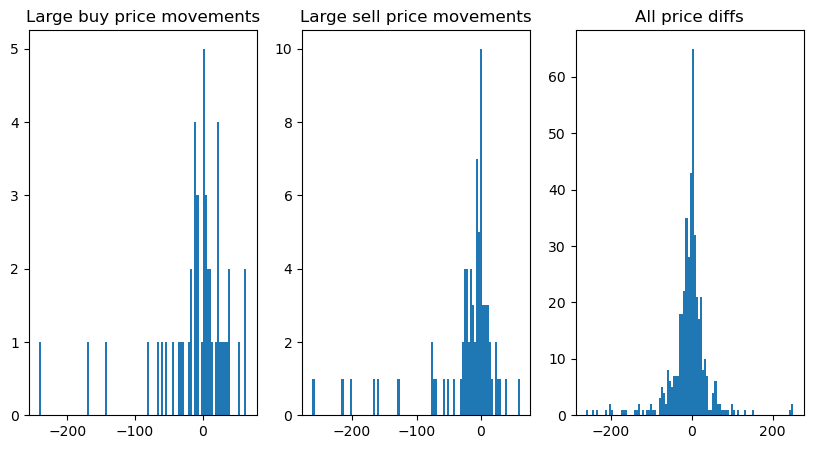


Price diff stats:
count    449.000000
mean      -7.365301
std       50.791460
min     -261.520000
25%      -20.280000
50%       -1.480000
75%       11.210000
max      251.030000
dtype: float64


In [590]:
price_diffs = []

X_dataset = []
y_dataset = []

y_ce_dataset = []

large_buy_price_movements = []
large_sell_price_movements = []

num = 0
for snapshot in all_nearby_snapshots:
    num += 1
    try:
        trade_data = snapshot['trade_data']
        brti_data = snapshot['brit_data']
        ob_data = snapshot['binance_ob']
    except:
        continue


    num_sequences = 10
    lag_window=5
    
    last_trades = pd.DataFrame(trade_data.head(num_sequences))
    last_ob = pd.DataFrame(ob_data.head(num_sequences))

    large_trade_timestamp = trade_data.iloc[0]['timestamp_ms']
    last_trade_sell_volume = trade_data.iloc[0]['sell_volume']
    last_trade_buy_volume = trade_data.iloc[0]['buy_volume']

    timestamp = trade_data['timestamp_ms']

    brti_data['diff'] = brti_data['brti_price'] - brti_data['brti_price'].shift(1)
    
    price_diff = None
    time_diff = None
    one_sec_price_diff = None
    # find first row that occured after the timestamp
    for i, row in enumerate(brti_data.iterrows()):
        row_timestamp = row[1]['timestamp_ms']
        if row_timestamp > large_trade_timestamp:

            try:
                # get previous row price
                previous_price = brti_data.iloc[i-1]['brti_price']
                current_price = brti_data.iloc[i]['brti_price']
                # next_timestamp = brti_data.iloc[i+1]['brti_price']
                # next_next_timestamp = brti_data.iloc[i+2]['brti_price']
                # price_diff_1 = current_price - previous_price
                # price_diff_2 = next_timestamp - previous_price
                # price_diff_3 = next_next_timestamp - previous_price

                one_sec_price_diff = current_price - previous_price

                # price_diff = (price_diff_1 + price_diff_2 + price_diff_3) / 3
    
            except Exception as e:
                print("Not enough brti data", e)

            break

    if one_sec_price_diff is not None and len(last_trades) == num_sequences and len(last_ob) == num_sequences and not math.isnan(one_sec_price_diff):
        price_diffs.append(one_sec_price_diff)

        if abs(one_sec_price_diff) > 20:
            y_ce_dataset.append(1)
        else:
            y_ce_dataset.append(0)

        if last_trade_sell_volume > 100:
            large_sell_price_movements.append(one_sec_price_diff)
        elif last_trade_buy_volume > 100:
            large_buy_price_movements.append(one_sec_price_diff)

        feature_matrix = make_features(last_ob, last_trades, lag_window)

        if feature_matrix is not None:
            target = one_sec_price_diff

            X_dataset.append(feature_matrix)
            y_dataset.append(target)


# describe large buy movements
print("Large buy movements:")
print(pd.Series(large_buy_price_movements).describe())

# describe large sell movements
print("Large sell movements:")
print(pd.Series(large_sell_price_movements).describe())

# histogram of time diffs and price diffs
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.hist(large_buy_price_movements, bins=100)
plt.title('Large buy price movements')

plt.subplot(1, 3, 2)
plt.hist(large_sell_price_movements, bins=100)
plt.title('Large sell price movements')

plt.subplot(1, 3, 3)
plt.hist(price_diffs, bins=100)
plt.title('All price diffs')

plt.show()

# print stats on time diff and price diff
print("\nPrice diff stats:")
print(pd.Series(price_diffs).describe())

# other

In [165]:
limit = 500000

In [68]:
# --- Read Data from the 'binance_trades' Table ---
table_name = "binance_trades"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_binance_trades = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_binance_trades)} rows from '{table_name}'.")
    display(df_binance_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 500000 rows from 'binance_trades'.


,timestamp_ms,sell_volume,buy_volume,vwap_sell_price,vwap_buy_price,total_volume,total_trade_count
0,1750542653229,0.140,0.003,101633.1,101633.2,0.143,12
1,1750542653077,0.000,0.004,0.0,101633.2,0.004,2
2,1750542652844,0.007,0.006,101633.1,101633.2,0.013,2
3,1750542652842,0.007,0.002,101633.1,101633.2,0.009,2
4,1750542652648,0.055,0.000,101633.1,0.0,0.055,3


In [69]:
# --- Read Data from the 'binance_orderbook_features' Table ---
table_name = "binance_orderbook_features"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_binance_ob = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_binance_ob)} rows from '{table_name}'.")
    display(df_binance_ob.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 500000 rows from 'binance_orderbook_features'.


,timestamp_ms,bid_l1_price,bid_l1_cumulative_qty,bid_l1_weighted_price,ask_l1_price,ask_l1_cumulative_qty,ask_l1_weighted_price,bid_l5_price,bid_l5_cumulative_qty,bid_l5_weighted_price,...,bid_l10_weighted_price,ask_l10_price,ask_l10_cumulative_qty,ask_l10_weighted_price,bid_l20_price,bid_l20_cumulative_qty,bid_l20_weighted_price,ask_l20_price,ask_l20_cumulative_qty,ask_l20_weighted_price
0,1750542653340,101633.1,0.039,101633.1,101633.2,9.491,101633.2,101632.2,0.508,101632.916929,...,101632.537662,101635.1,20.514,101633.938057,101628.3,2.233,101630.548768,101636.7,20.950,101633.974134
1,1750542653213,101633.1,0.108,101633.1,101633.2,8.270,101633.2,101632.2,0.577,101632.938821,...,101632.594307,101635.1,19.293,101633.984766,101628.3,2.302,101630.625239,101636.7,19.729,101634.022044
2,1750542653077,101633.1,0.245,101633.1,101633.2,8.271,101633.2,101632.2,0.714,101632.969748,...,101632.678589,101635.1,19.347,101633.985011,101628.3,2.439,101630.764248,101636.7,19.783,101634.022181
3,1750542652842,101633.1,0.252,101633.1,101633.2,8.130,101633.2,101632.2,0.721,101632.971012,...,101632.685024,101635.1,19.494,101633.988689,101628.5,2.434,101630.540961,101636.8,19.931,101634.025709
4,1750542652648,101633.1,0.260,101633.1,101633.2,8.161,101633.2,101632.2,0.729,101632.972428,...,101632.688995,101635.1,19.526,101633.987499,101628.5,2.442,101630.549345,101636.8,19.963,101634.024485


In [70]:
# --- Read Data from the 'brti_prices' Table ---
table_name = "brti_prices"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_brti = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_brti)} rows from '{table_name}'.")
    display(df_brti.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 75780 rows from 'brti_prices'.


,timestamp_ms,brti_price,simple_average
0,1750542597897,101800.53,101706.109500
1,1750542594550,101797.77,101703.652500
2,1750542591518,101796.46,101701.065833
3,1750542588658,101797.73,101698.558500
4,1750542586024,101789.52,101696.166667


In [71]:
df_brti['time_delta'] = df_brti['timestamp_ms'] - df_brti['timestamp_ms'].shift(1)

df_brti['time_delta'].describe()

count     75779.000000
mean      -1432.074704
std        3537.553387
min     -330547.000000
25%       -1070.000000
50%       -1002.000000
75%        -960.000000
max        -303.000000
Name: time_delta, dtype: float64

# cleaning brti data

In [7]:
import numpy as np

In [72]:
# find all valid sequences 

def standardize_financial_data(df):
    """
    Standardize financial data by rounding timestamps up to nearest second
    and keeping the most recent price for duplicate timestamps.
    
    Parameters:
    df: DataFrame with columns 'timestamp_ms' and 'price'
    
    Returns:
    DataFrame with standardized timestamps (every 1000ms)
    """
    # Create a copy to avoid modifying original data
    df_clean = df.copy()
    
    # Store original timestamp for tie-breaking
    df_clean['original_timestamp'] = df_clean['timestamp_ms']
    
    # Round UP to nearest 1000ms - simpler approach to avoid overflow
    df_clean['timestamp_ms'] = ((df_clean['timestamp_ms'] + 999) // 1000) * 1000
    
    # Sort by rounded timestamp, then by original timestamp (descending for most recent)
    df_clean = df_clean.sort_values(['timestamp_ms', 'original_timestamp'], 
                                   ascending=[True, False])
    
    # Keep only the first occurrence (which is the most recent due to sorting)
    df_clean = df_clean.drop_duplicates(subset=['timestamp_ms'], keep='first')
    
    # Clean up and return only the required columns
    df_result = df_clean[['timestamp_ms', 'brti_price']].reset_index(drop=True)
    
    return df_result

def find_consecutive_sequences(df):
    """
    Find all valid consecutive sequences of seconds in the standardized data.
    
    Parameters:
    df: DataFrame with standardized timestamps (every 1000ms) and prices
    
    Returns:
    List of DataFrames, each containing a consecutive sequence
    """
    # Sort by timestamp to ensure proper order
    df_sorted = df.sort_values('timestamp_ms').reset_index(drop=True)
    
    # Calculate differences between consecutive timestamps
    df_sorted['time_diff'] = df_sorted['timestamp_ms'].diff()
    
    # Mark where new sequences start (diff != 1000ms or first row)
    df_sorted['new_sequence'] = (df_sorted['time_diff'] != 1000) | (df_sorted['time_diff'].isna())
    
    # Create sequence groups
    df_sorted['sequence_id'] = df_sorted['new_sequence'].cumsum()
    
    # Split into separate sequences
    sequences = []
    for seq_id in df_sorted['sequence_id'].unique():
        sequence_df = df_sorted[df_sorted['sequence_id'] == seq_id][['timestamp_ms', 'brti_price']].copy()
        sequences.append(sequence_df.reset_index(drop=True))
    
    return sequences

def get_sequence_info(sequences):
    """
    Get information about each sequence.
    
    Parameters:
    sequences: List of DataFrames from find_consecutive_sequences
    
    Returns:
    DataFrame with sequence statistics
    """
    info = []
    for i, seq in enumerate(sequences):
        info.append({
            'sequence_id': i,
            'length': len(seq),
            'start_time': seq['timestamp_ms'].iloc[0],
            'end_time': seq['timestamp_ms'].iloc[-1],
            'duration_seconds': len(seq)
        })
    
    return pd.DataFrame(info)

def standardize_and_find_sequences(df, min_sequence_length=10):
    """
    Complete pipeline: standardize data and find consecutive sequences.
    
    Parameters:
    df: Original DataFrame with timestamp_ms and price
    min_sequence_length: Minimum length of sequences to keep
    
    Returns:
    Tuple of (all_sequences, valid_sequences, sequence_info)
    """
    # First standardize the data
    df_standardized = standardize_financial_data(df)
    
    # Find consecutive sequences
    all_sequences = find_consecutive_sequences(df_standardized)
    
    # Filter sequences by minimum length
    valid_sequences = [seq for seq in all_sequences if len(seq) >= min_sequence_length]
    
    # Get sequence information
    sequence_info = get_sequence_info(all_sequences)
    
    return all_sequences, valid_sequences, sequence_info

all_seqs, valid_seqs, info = standardize_and_find_sequences(df_brti, min_sequence_length=2)
print(f"Found {len(all_seqs)} total sequences, {len(valid_seqs)} valid sequences")
print(info)

Found 13280 total sequences, 5961 valid sequences
       sequence_id  length     start_time       end_time  duration_seconds
0                0       3  1750434077000  1750434079000                 3
1                1       3  1750434081000  1750434083000                 3
2                2       3  1750434085000  1750434087000                 3
3                3       3  1750434089000  1750434091000                 3
4                4       3  1750434093000  1750434095000                 3
...            ...     ...            ...            ...               ...
13275        13275       1  1750542587000  1750542587000                 1
13276        13276       1  1750542589000  1750542589000                 1
13277        13277       1  1750542592000  1750542592000                 1
13278        13278       1  1750542595000  1750542595000                 1
13279        13279       1  1750542598000  1750542598000                 1

[13280 rows x 5 columns]


# feature engineering on orderbook and trades

In [73]:
df_binance_ob['l1_spread'] = df_binance_ob['ask_l1_price'] - df_binance_ob['bid_l1_price']
df_binance_ob['l5_spread'] = df_binance_ob['ask_l5_price'] - df_binance_ob['bid_l5_price']
df_binance_ob['l10_spread'] = df_binance_ob['ask_l10_price'] - df_binance_ob['bid_l10_price']
df_binance_ob['l20_spread'] = df_binance_ob['ask_l20_price'] - df_binance_ob['bid_l20_price']

df_binance_ob = df_binance_ob.drop(columns=[ 
                                            'bid_l1_price', 'ask_l1_price', 
                                            'bid_l5_price', 'ask_l5_price', 
                                            'bid_l10_price', 'ask_l10_price', 
                                            'bid_l20_price', 'ask_l20_price',
                                            'bid_l1_weighted_price', 'ask_l1_weighted_price',
                                            'bid_l5_weighted_price', 'ask_l5_weighted_price',
                                            'bid_l10_weighted_price', 'ask_l10_weighted_price',
                                            'bid_l20_weighted_price', 'ask_l20_weighted_price'
                                            ])

df_binance_trades = df_binance_trades.drop(columns=['vwap_sell_price', 'vwap_buy_price'])

# standardizing binance data

In [74]:
def standardize_financial_data_100ms(df):
    """
    Standardize financial data by rounding timestamps up to nearest 100ms
    and keeping the most recent price for duplicate timestamps.
    
    Parameters:
    df: DataFrame with columns 'timestamp_ms' and 'price'
    
    Returns:
    DataFrame with standardized timestamps (every 100ms)
    """
    # Create a copy to avoid modifying original data
    df_clean = df.copy()
    
    # Store original timestamp for tie-breaking
    df_clean['original_timestamp'] = df_clean['timestamp_ms']
    
    # Round UP to nearest 100ms
    df_clean['timestamp_ms'] = ((df_clean['timestamp_ms'] + 99) // 100) * 100
    
    # Sort by rounded timestamp, then by original timestamp (descending for most recent)
    df_clean = df_clean.sort_values(['timestamp_ms', 'original_timestamp'], 
                                   ascending=[True, False])
    
    # Keep only the first occurrence (which is the most recent due to sorting)
    df_clean = df_clean.drop_duplicates(subset=['timestamp_ms'], keep='first')
    
    # Clean up and return only the required columns
    df_result = df_clean.reset_index(drop=True)
    
    return df_result

standardized_orderbook_features = standardize_financial_data_100ms(df_binance_ob)
standardized_trades = standardize_financial_data_100ms(df_binance_trades)

standardized_orderbook_features.head()

,timestamp_ms,bid_l1_cumulative_qty,ask_l1_cumulative_qty,bid_l5_cumulative_qty,ask_l5_cumulative_qty,bid_l10_cumulative_qty,ask_l10_cumulative_qty,bid_l20_cumulative_qty,ask_l20_cumulative_qty,l1_spread,l5_spread,l10_spread,l20_spread,original_timestamp
0,1750478086200,4.592,12.146,5.158,12.207,6.279,13.123,6.482,14.789,0.1,1.7,3.1,6.9,1750478086129
1,1750478086300,4.596,12.146,5.162,12.207,6.283,13.123,6.486,14.578,0.1,1.7,3.1,6.8,1750478086253
2,1750478086400,4.602,12.072,5.168,12.133,6.289,13.049,6.492,14.504,0.1,1.7,3.1,6.6,1750478086367
3,1750478086500,4.605,12.080,5.171,12.141,6.340,13.249,6.543,14.451,0.1,1.7,3.2,6.7,1750478086470
4,1750478086700,4.648,12.139,5.875,12.390,6.431,13.113,6.678,14.571,0.1,1.8,3.4,7.2,1750478086667


In [76]:
def is_consecutive_timestamps(df, interval_ms=100):
    """
    Check if a dataframe has consecutive timestamps.
    
    Parameters:
    df: DataFrame with 'timestamp_ms' column
    interval_ms: Expected interval between consecutive timestamps in milliseconds (default 100)
    
    Returns:
    bool: True if all timestamps are consecutive, False otherwise
    """
    if len(df) <= 1:
        return True  # Single row or empty dataframe is considered consecutive
    
    # Sort by timestamp to ensure proper order
    df_sorted = df.sort_values('timestamp_ms').reset_index(drop=True)
    
    # Calculate differences between consecutive timestamps
    time_diffs = df_sorted['timestamp_ms'].diff().dropna()
    
    # Check if all differences equal the expected interval
    return (time_diffs == interval_ms).all()

In [85]:
from tqdm import tqdm

samples = []

for seq in tqdm(all_seqs):

    seq['target'] = seq['brti_price'].diff()
    seq = seq.dropna()

    # now find binance orderbook and trades CENTERED on each timestamp
    for row in seq.iterrows():
        timestamp = row[1]['timestamp_ms']
        target = row[1]['target']

        threshold = 500 # within the next 500ms
        binance_ob = standardized_orderbook_features[(standardized_orderbook_features['timestamp_ms'] - timestamp <= 500) & (standardized_orderbook_features['timestamp_ms'] - timestamp >= 0)]
        binance_trades = standardized_trades[(standardized_trades['timestamp_ms'] - timestamp <= 500) & (standardized_trades['timestamp_ms'] - timestamp >= 0)]

        if len(binance_ob) == 5 and len(binance_trades) == 5:
            # orderbook_good = is_consecutive_timestamps(binance_ob)
            # trades_good = is_consecutive_timestamps(binance_trades)

            sample = {
                'timestamp': timestamp,
                'target': target,
                'orderbook': binance_ob,
                'trades': binance_trades
            }
            samples.append(sample)
            
print(len(samples))

100%|██████████| 13280/13280 [06:22<00:00, 34.72it/s]  

4452


In [86]:
def extract_features_from_sample(sample):
    orderbook = sample['orderbook']
    trades = sample['trades']
    
    # Sort by timestamp to ensure proper order
    orderbook = orderbook.sort_values('timestamp_ms').reset_index(drop=True)
    trades = trades.sort_values('timestamp_ms').reset_index(drop=True)
    
    book_features = orderbook.columns
    trade_features = trades.columns

    num_features = len(orderbook.columns) + len(trades.columns)
    
    # Create feature matrix
    sequence_length = len(orderbook)
    feature_matrix = np.zeros((sequence_length, num_features))
    
    # Fill orderbook features (first 24 columns)
    for i, feature in enumerate(book_features):
        feature_matrix[:, i] = orderbook[feature].values
    
    # Fill trades features (last 6 columns)
    for i, feature in enumerate(trade_features):
        feature_matrix[:, len(book_features) + i] = trades[feature].values
    
    return feature_matrix

In [87]:
import matplotlib.pyplot as plt

(4452, 5, 20) (4452,)


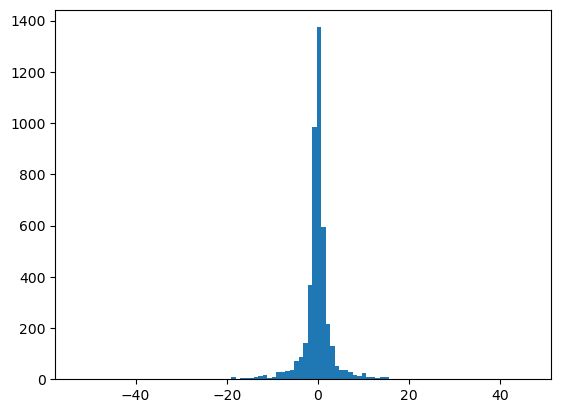

In [88]:
X = []
Y = []

for sample in samples:
    
    target = sample['target']
    orderbook = sample['orderbook']
    trades = sample['trades']   


    orderbook = orderbook.drop(columns=['timestamp_ms', 'original_timestamp'])
    trades = trades.drop(columns=['timestamp_ms', 'original_timestamp'])

    feature_matrix = extract_features_from_sample(sample)
    X.append(np.array(feature_matrix))
    Y.append(target)

X = np.array(X)
Y = np.array(Y)


print(X.shape, Y.shape)

plt.hist(Y, bins=100)
plt.show()

# 1D CNN Model

In [414]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # Skip connection adjustment if input/output channels differ
        self.skip_conv = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        
    def forward(self, x):
        identity = x
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # Adjust skip connection if needed
        if self.skip_conv:
            identity = self.skip_conv(identity)
            
        out += identity
        return F.relu(out)

class BTCPricePredictorCNN(nn.Module):
    def __init__(self, input_features=20, sequence_length=3):
        super(BTCPricePredictorCNN, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        
        # Initial conv layer
        self.initial_conv = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        
        # Residual blocks
        self.res_block1 = ResidualBlock1D(64, 32, kernel_size=3)
        self.res_block2 = ResidualBlock1D(32, 32, kernel_size=3)
        
        # Global average pooling (implemented as adaptive avg pool)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        
        # Final dense layers
        self.fc1 = nn.Linear(32, 32)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        # Input shape: (batch_size, sequence_length, input_features)
        # Conv1D expects: (batch_size, channels, sequence_length)
        x = x.transpose(1, 2)  # (batch_size, input_features, sequence_length)
        
        # Initial convolution
        x = F.relu(self.initial_conv(x))
        
        # Residual blocks
        x = self.res_block1(x)
        x = self.res_block2(x)
        
        # Global average pooling
        x = self.global_avg_pool(x)  # (batch_size, 32, 1)
        x = x.squeeze(-1)  # (batch_size, 32)
        
        # Final dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch_size, 1)
        
        return x

class ImprovedBTCPricePredictorCNN(nn.Module):
    def __init__(self, input_features=20, sequence_length=3):
        super(ImprovedBTCPricePredictorCNN, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        
        # More sophisticated architecture
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # Attention mechanism
        self.attention = nn.MultiheadAttention(64, num_heads=4, batch_first=True)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Final dense layers with better initialization
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
        # Initialize weights properly
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # Input shape: (batch_size, sequence_length, input_features)
        # Conv1D expects: (batch_size, channels, sequence_length)
        x = x.transpose(1, 2)  # (batch_size, input_features, sequence_length)
        
        # Feature extraction
        x = self.feature_extractor(x)  # (batch_size, 64, sequence_length)
        
        # Transpose for attention
        x = x.transpose(1, 2)  # (batch_size, sequence_length, 64)
        
        # Self-attention
        x, _ = self.attention(x, x, x)
        
        # Global pooling
        x = x.transpose(1, 2)  # (batch_size, 64, sequence_length)
        x = self.global_pool(x)  # (batch_size, 64, 1)
        x = x.squeeze(-1)  # (batch_size, 64)
        
        # Final dense layers
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.fc3(x)
        
        return x

def train_improved_model(model, train_loader, val_loader, scheduler, criterion, optimizer, epochs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    

    best_val_loss = float('inf')
    patience_counter = 0
    patience = 300
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for sequences, targets in train_loader:
            sequences, targets = sequences.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences).squeeze()
            loss = criterion(outputs, targets)
            
            # Add L2 regularization manually if needed
            l2_lambda = 0.001
            l2_reg = torch.tensor(0.).to(device)
            for param in model.parameters():
                l2_reg += torch.norm(param)
            loss += l2_lambda * l2_reg
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences, targets = sequences.to(device), targets.to(device)
                outputs = model(sequences).squeeze()
                val_loss += criterion(outputs, targets).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_improved_btc_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curves')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses[-50:], label='Train Loss (last 50)')
    plt.plot(val_losses[-50:], label='Val Loss (last 50)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curves (Last 50 Epochs)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return model

# Training utilities
class BTCDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, targets, train_split=0.8, random_state=42):
        """
        sequences: numpy array of shape (n_samples, sequence_length, features)
        targets: numpy array of shape (n_samples,)
        train_split: fraction of data to use for training (default 0.8 = 80% train, 20% val)
        random_state: for reproducible splits
        """
        self.sequences = torch.FloatTensor(sequences)
        self.targets = torch.FloatTensor(targets)
        self.train_split = train_split
        self.random_state = random_state        
        # Create train/val split indices
        n_samples = len(self.sequences)
        n_train = int(n_samples * train_split)
        
        # Create indices and shuffle them
        indices = torch.randperm(n_samples, generator=torch.Generator().manual_seed(random_state))
        
        self.train_indices = indices[:n_train]
        self.val_indices = indices[n_train:]
        
        print(f"Dataset split: {len(self.train_indices)} train, {len(self.val_indices)} validation")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]
    
    def get_train_loader(self, batch_size=32, shuffle=True):
        """Get training DataLoader"""
        train_subset = torch.utils.data.Subset(self, self.train_indices)
        return torch.utils.data.DataLoader(
            train_subset, 
            batch_size=batch_size, 
            shuffle=shuffle
        )
    
    def get_val_loader(self, batch_size=32, shuffle=False):
        """Get validation DataLoader"""
        val_subset = torch.utils.data.Subset(self, self.val_indices)
        return torch.utils.data.DataLoader(
            val_subset, 
            batch_size=batch_size, 
            shuffle=shuffle
        )

# Example usage and training setup
def create_model_and_train():
    # Model initialization
    model = BTCPricePredictorCNN(input_features=25, sequence_length=5)
    
    # Loss and optimizer
    criterion = nn.MSELoss()  # or nn.L1Loss() for MAE
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    return model, criterion, optimizer, scheduler

# Fast inference function
def fast_inference(model, sequence):
    """
    Fast inference for a single sequence
    sequence: torch.Tensor of shape (sequence_length, features) or (1, sequence_length, features)
    """
    model.eval()
    with torch.no_grad():
        if sequence.dim() == 2:
            sequence = sequence.unsqueeze(0)  # Add batch dimension
        prediction = model(sequence)
        return prediction.item()

# Training loop example
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on {device}")
    model.to(device)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for sequences, targets in train_loader:
            sequences, targets = sequences.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences).squeeze()
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences, targets = sequences.to(device), targets.to(device)
                outputs = model(sequences).squeeze()
                val_loss += criterion(outputs, targets).item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_btc_model.pth')
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

# Model info and speed test
def model_info(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Speed test
    model.eval()

    seq_len = model.sequence_length 
    features = model.input_features

    dummy_input = torch.randn(1, seq_len, features)
    
    # Warmup
    with torch.no_grad():
        for _ in range(100):
            _ = model(dummy_input)
    
    # Time it
    import time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model(dummy_input)
    end_time = time.time()
    
    avg_inference_time = (end_time - start_time) / 1000
    print(f"Average inference time: {avg_inference_time*1000:.3f} ms")

In [415]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np

class BTCDataset(Dataset):
    def __init__(self, sequences, targets, sequence_scaler=None, target_scaler=None, fit_scalers=True):
        """
        Enhanced BTC Dataset with built-in scaling
        
        Args:
            sequences: numpy array of shape (n_samples, sequence_length, n_features)
            targets: numpy array of shape (n_samples,)
            sequence_scaler: sklearn scaler for sequences (if None, will create new StandardScaler)
            target_scaler: sklearn scaler for targets (if None, will create new StandardScaler)
            fit_scalers: whether to fit the scalers on this data (True for training, False for validation/test)
        """
        self.sequences = sequences
        self.targets = targets
        
        # Initialize scalers - CRITICAL: Always create scalers if not provided
        if sequence_scaler is None:
            self.sequence_scaler = StandardScaler()
        else:
            self.sequence_scaler = sequence_scaler
            
        if target_scaler is None:
            self.target_scaler = StandardScaler()
        else:
            self.target_scaler = target_scaler
        
        # Scale the sequences
        self.scaled_sequences = self._scale_sequences(fit_scalers)
        
        # Scale the targets
        self.scaled_targets = self._scale_targets(fit_scalers)
        
        print(f"Dataset created with {len(self.sequences)} samples")
        print(f"Sequence shape: {self.scaled_sequences.shape}")
        print(f"Target shape: {self.scaled_targets.shape}")
        
    def _scale_sequences(self, fit_scalers):
        """Scale the sequence data"""
        # Reshape for sklearn: (n_samples * sequence_length, n_features)
        original_shape = self.sequences.shape
        sequences_reshaped = self.sequences.reshape(-1, original_shape[-1])
        
        if fit_scalers:
            sequences_scaled = self.sequence_scaler.fit_transform(sequences_reshaped)
            print(f"Fitted sequence scaler - Mean: {self.sequence_scaler.mean_[:5]}, Std: {self.sequence_scaler.scale_[:5]}")
        else:
            sequences_scaled = self.sequence_scaler.transform(sequences_reshaped)
            print(f"Applied sequence scaler (no fitting)")
        
        # Reshape back to original shape
        sequences_scaled = sequences_scaled.reshape(original_shape)
        
        return sequences_scaled
    
    def _scale_targets(self, fit_scalers):
        """Scale the target data"""
        if fit_scalers:
            targets_scaled = self.target_scaler.fit_transform(self.targets.reshape(-1, 1)).flatten()
            print(f"Fitted target scaler - Mean: {self.target_scaler.mean_[0]:.4f}, Std: {self.target_scaler.scale_[0]:.4f}")
        else:
            targets_scaled = self.target_scaler.transform(self.targets.reshape(-1, 1)).flatten()
            print(f"Applied target scaler (no fitting)")
        
        return targets_scaled
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.scaled_sequences[idx]), torch.FloatTensor([self.scaled_targets[idx]])
    
    def get_train_loader(self, batch_size=32, shuffle=True):
        return DataLoader(self, batch_size=batch_size, shuffle=shuffle)
    
    def get_val_loader(self, batch_size=32, shuffle=False):
        return DataLoader(self, batch_size=batch_size, shuffle=shuffle)
    
    def get_scalers(self):
        """Return both scalers for later use"""
        return self.sequence_scaler, self.target_scaler
    
    def denormalize_predictions(self, predictions):
        """Convert normalized predictions back to original scale"""
        return self.target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()

def create_datasets(X_DATASET, Y_DATASET, test_size=0.2, random_state=42):
    """
    Create training and validation datasets with proper scaling
    """
    from sklearn.model_selection import train_test_split
    
    # Split the data
    X_train, X_val, y_train, y_val = train_test_split(
        X_DATASET, Y_DATASET, test_size=test_size, random_state=random_state
    )
    
    print("=== Creating Training Dataset ===")
    train_dataset = BTCDataset(X_train, y_train, fit_scalers=True)
    
    print("\n=== Creating Validation Dataset ===")
    # Pass both scalers from training dataset
    val_dataset = BTCDataset(X_val, y_val, 
                            sequence_scaler=train_dataset.sequence_scaler,
                            target_scaler=train_dataset.target_scaler,
                            fit_scalers=False)
    
    return train_dataset, val_dataset

# Usage:
def setup_training_data(X_DATASET, Y_DATASET):
    """
    Complete setup for your training data
    """
    # Create datasets
    train_dataset, val_dataset = create_datasets(X_DATASET, Y_DATASET)
    
    # Create data loaders
    train_loader = train_dataset.get_train_loader(batch_size=32, shuffle=True)
    val_loader = val_dataset.get_val_loader(batch_size=32, shuffle=False)
    
    # Get scalers for later use
    sequence_scaler, target_scaler = train_dataset.get_scalers()
    
    return train_loader, val_loader, sequence_scaler, target_scaler

# Test the fix:
def test_dataset_creation():
    """Test that both datasets have the target_scaler attribute"""
    # Create dummy data
    X_dummy = np.random.randn(100, 5, 20)
    y_dummy = np.random.randn(100)
    
    try:
        train_dataset, val_dataset = create_datasets(X_dummy, y_dummy)
        
        # Check that both datasets have target_scaler
        print(f"Train dataset has target_scaler: {hasattr(train_dataset, 'target_scaler')}")
        print(f"Val dataset has target_scaler: {hasattr(val_dataset, 'target_scaler')}")
        
        # Test denormalization
        dummy_predictions = np.random.randn(10)
        denorm_predictions = train_dataset.denormalize_predictions(dummy_predictions)
        print(f"Denormalization works: {len(denorm_predictions) == len(dummy_predictions)}")
        
        return True
        
    except Exception as e:
        print(f"Error: {e}")
        return False

# Run test
test_dataset_creation()

=== Creating Training Dataset ===
Fitted sequence scaler - Mean: [-0.00359732 -0.0420695  -0.04077705  0.0387361   0.06360941], Std: [0.99180797 1.00919485 0.99746252 1.01422915 0.92156619]
Fitted target scaler - Mean: -0.0699, Std: 1.0910
Dataset created with 80 samples
Sequence shape: (80, 5, 20)
Target shape: (80,)

=== Creating Validation Dataset ===
Applied sequence scaler (no fitting)
Applied target scaler (no fitting)
Dataset created with 20 samples
Sequence shape: (20, 5, 20)
Target shape: (20,)
Train dataset has target_scaler: True
Val dataset has target_scaler: True
Denormalization works: True


True

In [371]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super(TemporalBlock, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              dilation=dilation, padding=(kernel_size-1)*dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 
                              dilation=dilation, padding=(kernel_size-1)*dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # Proper skip connection
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        
    def forward(self, x):
        identity = x
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        if self.downsample:
            identity = self.downsample(identity)
        
        # Ensure dimensions match before adding
        if out.size() != identity.size():
            # Pad or crop identity to match output size
            if out.size(-1) > identity.size(-1):
                # Pad identity
                pad_size = out.size(-1) - identity.size(-1)
                identity = F.pad(identity, (0, pad_size))
            else:
                # Crop identity
                identity = identity[:, :, :out.size(-1)]
        
        out += identity
        return F.relu(out)

class AdvancedFinancialPredictor(nn.Module):
    def __init__(self, input_features=20, sequence_length=5, hidden_dim=128):
        super(AdvancedFinancialPredictor, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        self.hidden_dim = hidden_dim
        
        # 1. Multi-scale Feature Extraction
        self.multi_scale_conv = nn.ModuleList([
            nn.Conv1d(input_features, hidden_dim//4, kernel_size=1, padding=0),
            nn.Conv1d(input_features, hidden_dim//4, kernel_size=3, padding=1),
            nn.Conv1d(input_features, hidden_dim//4, kernel_size=5, padding=2),
            nn.Conv1d(input_features, hidden_dim//4, kernel_size=7, padding=3),
        ])
        
        # 2. TCN blocks with proper dimensions
        self.tcn_blocks = nn.ModuleList([
            TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=1),
            TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2),
            TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4),
        ])
        
        # 3. LSTM layer
        self.lstm = nn.LSTM(hidden_dim, hidden_dim//2, num_layers=2, 
                           bidirectional=True, batch_first=True, dropout=0.2)
        
        # 4. Attention mechanism
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=8, 
                                             dropout=0.1, batch_first=True)
        
        # 5. Global pooling
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        
        # 6. Dense layers
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        
        # 7. Dropout and normalization
        self.dropout = nn.Dropout(0.3)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight' in name:
                        nn.init.orthogonal_(param)
                    elif 'bias' in name:
                        nn.init.constant_(param, 0)
    
    def forward(self, x):
        # Input: (batch_size, sequence_length, input_features)
        batch_size = x.size(0)
        
        # Transpose for conv1d: (batch_size, input_features, sequence_length)
        x = x.transpose(1, 2)
        
        # 1. Multi-scale feature extraction
        multi_scale_features = []
        for conv in self.multi_scale_conv:
            multi_scale_features.append(conv(x))
        x = torch.cat(multi_scale_features, dim=1)  # (batch_size, hidden_dim, sequence_length)
        
        # 2. TCN blocks
        for tcn_block in self.tcn_blocks:
            x = tcn_block(x)
        
        # 3. Transpose for LSTM: (batch_size, sequence_length, hidden_dim)
        x = x.transpose(1, 2)
        
        # 4. LSTM processing
        lstm_out, _ = self.lstm(x)
        
        # 5. Self-attention
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        
        # 6. Layer normalization
        x = self.layer_norm(attn_out)
        
        # 7. Global pooling
        x_transposed = x.transpose(1, 2)  # (batch_size, hidden_dim, sequence_length)
        avg_pooled = self.adaptive_pool(x_transposed).squeeze(-1)
        max_pooled = self.max_pool(x_transposed).squeeze(-1)
        pooled = torch.cat([avg_pooled, max_pooled], dim=1)  # (batch_size, hidden_dim * 2)
        
        # 8. Dense layers
        x = F.relu(self.fc1(pooled))
        x = self.dropout(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        
        output = self.fc3(x)
        
        return output

# Simplified but effective model
class SimpleAdvancedModel(nn.Module):
    def __init__(self, input_features=20, sequence_length=5):
        super(SimpleAdvancedModel, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        
        # Feature extraction
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # LSTM layer
        self.lstm = nn.LSTM(64, 32, num_layers=2, bidirectional=True, 
                           batch_first=True, dropout=0.2)
        
        # Attention
        self.attention = nn.MultiheadAttention(64, num_heads=4, 
                                             dropout=0.1, batch_first=True)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Dense layers
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)
        
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # Input: (batch_size, sequence_length, input_features)
        batch_size = x.size(0)
        
        # Transpose for conv1d
        x = x.transpose(1, 2)  # (batch_size, input_features, sequence_length)
        
        # Feature extraction
        x = self.feature_extractor(x)  # (batch_size, 64, sequence_length)
        
        # Transpose for LSTM
        x = x.transpose(1, 2)  # (batch_size, sequence_length, 64)
        
        # LSTM
        lstm_out, _ = self.lstm(x)
        
        # Attention
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        
        # Global pooling
        x = attn_out.transpose(1, 2)  # (batch_size, 64, sequence_length)
        x = self.global_pool(x)  # (batch_size, 64, 1)
        x = x.squeeze(-1)  # (batch_size, 64)
        
        # Dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Test the model
def test_model():
    # Test data
    batch_size = 4
    sequence_length = 5
    input_features = 20
    
    x = torch.randn(batch_size, sequence_length, input_features)
    
    # Test SimpleAdvancedModel
    model = SimpleAdvancedModel(input_features, sequence_length)
    output = model(x)
    print(f"SimpleAdvancedModel output shape: {output.shape}")
    
    # Test AdvancedFinancialPredictor
    model2 = AdvancedFinancialPredictor(input_features, sequence_length)
    output2 = model2(x)
    print(f"AdvancedFinancialPredictor output shape: {output2.shape}")
    
    return model, model2

In [372]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def normalize_features(X, scaler=None, fit=True):
    """
    Normalize features using Z-score normalization
    """
    if fit:
        scaler = StandardScaler()
        # Reshape for sklearn: (n_samples, n_features)
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_normalized = scaler.fit_transform(X_reshaped)
        # Reshape back: (n_samples, sequence_length, n_features)
        X_normalized = X_normalized.reshape(X.shape)
        return X_normalized, scaler
    else:
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_normalized = scaler.transform(X_reshaped)
        X_normalized = X_normalized.reshape(X.shape)
        return X_normalized

from sklearn.preprocessing import MinMaxScaler

def normalize_bounded_features(X, scaler=None, fit=True):
    """
    For features that should be between 0 and 1
    """
    if fit:
        scaler = MinMaxScaler()
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_normalized = scaler.fit_transform(X_reshaped)
        X_normalized = X_normalized.reshape(X.shape)
        return X_normalized, scaler
    else:
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_normalized = scaler.transform(X_reshaped)
        X_normalized = X_normalized.reshape(X.shape)
        return X_normalized

# make it a CE training task

=== Binary Classification Analysis ===
Threshold: $20.0
Class 0 (≤$20.0): 234 samples (60.6%)
Class 1 (>$20.0): 152 samples (39.4%)


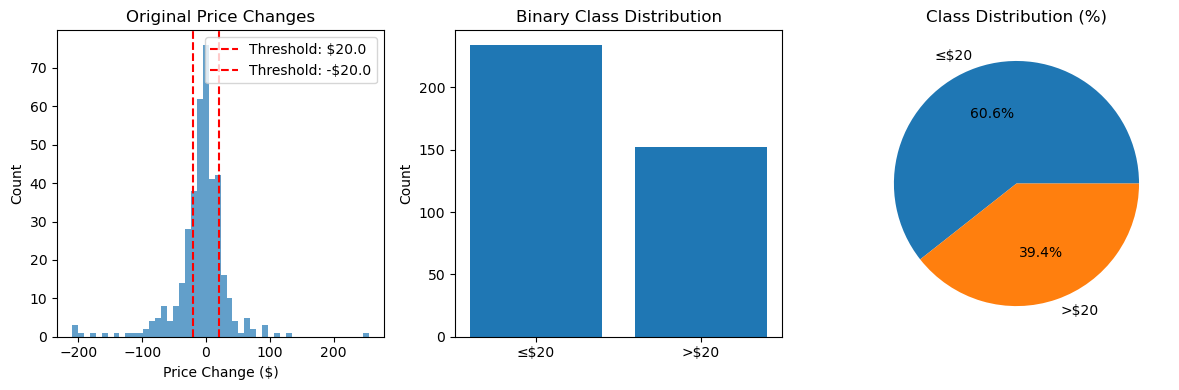

In [442]:
import numpy as np
import matplotlib.pyplot as plt

def convert_to_binary_classification(Y_DATASET, threshold=20.0):
    """
    Convert continuous price changes to binary classification:
    0: Price change <= threshold
    1: Price change > threshold (significant move)
    """
    # Convert to binary labels
    binary_targets = (np.abs(Y_DATASET) > threshold).astype(int)
    
    # Analyze the distribution
    unique, counts = np.unique(binary_targets, return_counts=True)
    class_distribution = dict(zip(unique, counts))
    
    print(f"=== Binary Classification Analysis ===")
    print(f"Threshold: ${threshold}")
    print(f"Class 0 (≤${threshold}): {class_distribution[0]} samples ({class_distribution[0]/len(Y_DATASET)*100:.1f}%)")
    print(f"Class 1 (>${threshold}): {class_distribution[1]} samples ({class_distribution[1]/len(Y_DATASET)*100:.1f}%)")
    
    # Plot distribution
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.hist(Y_DATASET, bins=50, alpha=0.7)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold: ${threshold}')
    plt.axvline(-threshold, color='red', linestyle='--', label=f'Threshold: -${threshold}')
    plt.title('Original Price Changes')
    plt.xlabel('Price Change ($)')
    plt.ylabel('Count')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.bar(['≤$20', '>$20'], [class_distribution[0], class_distribution[1]])
    plt.title('Binary Class Distribution')
    plt.ylabel('Count')
    
    plt.subplot(1, 3, 3)
    plt.pie([class_distribution[0], class_distribution[1]], 
            labels=['≤$20', '>$20'], autopct='%1.1f%%')
    plt.title('Class Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
    return binary_targets

# Convert your targets
Y_BINARY = convert_to_binary_classification(y_dataset, threshold=20.0)

In [562]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class BTCDatasetClassification(Dataset):
    def __init__(self, sequences, targets, sequence_scaler=None, fit_scalers=True):
        """
        BTC Dataset for classification with built-in scaling
        """
        self.sequences = sequences
        self.targets = targets
        
        # Scale sequences
        if fit_scalers:
            self.sequence_scaler = StandardScaler()
            # Reshape for sklearn: (n_samples, n_features)
            sequences_reshaped = sequences.reshape(-1, sequences.shape[-1])
            self.scaled_sequences = self.sequence_scaler.fit_transform(sequences_reshaped)
            # Reshape back: (n_samples, sequence_length, n_features)
            self.scaled_sequences = self.scaled_sequences.reshape(sequences.shape)
        else:
            self.sequence_scaler = sequence_scaler
            sequences_reshaped = sequences.reshape(-1, sequences.shape[-1])
            self.scaled_sequences = self.sequence_scaler.transform(sequences_reshaped)
            self.scaled_sequences = self.scaled_sequences.reshape(sequences.shape)
        
        print(f"Dataset created with {len(self.sequences)} samples")
        print(f"Sequence shape: {self.scaled_sequences.shape}")
        print(f"Target shape: {self.targets.shape}")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = torch.FloatTensor(self.scaled_sequences[idx])
        target = torch.LongTensor([self.targets[idx]])  # For classification
        return sequence, target
    
    def get_train_loader(self, batch_size=32, shuffle=True, weighted_sampling=True):
        if weighted_sampling:
            # Calculate class weights for weighted sampling
            class_counts = np.bincount(self.targets)
            class_weights = 1.0 / class_counts
            sample_weights = class_weights[self.targets]
            
            # Create weighted sampler
            sampler = WeightedRandomSampler(
                weights=sample_weights,
                num_samples=len(self.targets),
                replacement=True
            )
            
            return DataLoader(self, batch_size=batch_size, sampler=sampler)
        else:
            return DataLoader(self, batch_size=batch_size, shuffle=shuffle)
    
    def get_val_loader(self, batch_size=32, shuffle=False):
        return DataLoader(self, batch_size=batch_size, shuffle=shuffle)

def setup_classification_data_with_weighted_sampling(X_DATASET, Y_BINARY, train_batch_size=32, val_batch_size=32):
    """
    Setup with weighted sampling for imbalanced classes
    """
    # Check class distribution
    unique_classes, class_counts = np.unique(Y_BINARY, return_counts=True)
    print(f"Original class distribution: {dict(zip(unique_classes, class_counts))}")
    
    # Split data (without stratification to avoid the error)
    X_train, X_val, y_train, y_val = train_test_split(
        X_DATASET, Y_BINARY, test_size=0.2, random_state=42, stratify=None
    )
    
    print(f"Training set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples")
    
    # Check class distribution in splits
    train_classes, train_counts = np.unique(y_train, return_counts=True)
    val_classes, val_counts = np.unique(y_val, return_counts=True)
    
    print(f"Training class distribution: {dict(zip(train_classes, train_counts))}")
    print(f"Validation class distribution: {dict(zip(val_classes, val_counts))}")
    
    # Create datasets
    print("=== Creating Training Dataset ===")
    train_dataset = BTCDatasetClassification(X_train, y_train, fit_scalers=True)
    
    print("=== Creating Validation Dataset ===")
    val_dataset = BTCDatasetClassification(X_val, y_val, fit_scalers=False, 
                                         sequence_scaler=train_dataset.sequence_scaler)
    
    # Create data loaders with weighted sampling
    train_loader = train_dataset.get_train_loader(batch_size=train_batch_size, weighted_sampling=True)
    val_loader = val_dataset.get_val_loader(batch_size=val_batch_size, shuffle=False)
    
    return train_loader, val_loader, train_dataset.sequence_scaler

def plot_roc_curve(y_true, y_pred_proba, title="ROC Curve"):
    """
    Plot ROC curve with AUC score
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return roc_auc, fpr, tpr, thresholds

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Plot confusion matrix with heatmap
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['≤$20', '>$20'], 
                yticklabels=['≤$20', '>$20'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm

def evaluate_classification_model(model, val_loader, device='cpu'):
    """
    Comprehensive evaluation of classification model
    """
    model.eval()
    model = model.to(device)
    
    all_predictions = []
    all_probabilities = []
    all_targets = []
    
    with torch.no_grad():
        for sequences, targets in val_loader:
            sequences = sequences.to(device)
            targets = targets.to(device)
            
            # Get model outputs
            outputs = model(sequences)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)
            
            # Collect results
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())  # Probability of positive class
            all_targets.extend(targets.squeeze().cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    all_targets = np.array(all_targets)
    
    # Print classification report
    print("Classification Report:")
    print(classification_report(all_targets, all_predictions, target_names=['≤$20', '>$20']))
    
    # Plot confusion matrix
    plot_confusion_matrix(all_targets, all_predictions)
    
    # Plot ROC curve
    roc_auc, fpr, tpr, thresholds = plot_roc_curve(all_targets, all_probabilities)
    
    # Additional metrics
    print(f"\nROC AUC: {roc_auc:.3f}")
    print(f"Number of samples: {len(all_targets)}")
    print(f"Class distribution: {np.bincount(all_targets)}")
    
    return all_predictions, all_probabilities, all_targets, roc_auc

def create_weighted_loss_function(class_counts):
    """
    Create weighted loss function for imbalanced classes
    """
    # Calculate class weights (inverse of class frequencies)
    total_samples = sum(class_counts)
    class_weights = torch.FloatTensor([total_samples / (len(class_counts) * count) for count in class_counts])
    
    print(f"Class weights: {class_weights}")
    
    return nn.CrossEntropyLoss(weight=class_weights)

In [599]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BTCMarketMoveClassifier(nn.Module):
    def __init__(self, input_features=20, sequence_length=5, num_classes=2):
        super(BTCMarketMoveClassifier, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        self.num_classes = num_classes
        
        # Feature extraction
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # Attention mechanism
        self.attention = nn.MultiheadAttention(128, num_heads=4, dropout=0.1, batch_first=True)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
        
        # Initialize weights
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Input: (batch_size, sequence_length, input_features)
        batch_size = x.size(0)
        
        # Transpose for conv1d
        x = x.transpose(1, 2)  # (batch_size, input_features, sequence_length)
        
        # Feature extraction
        x = self.feature_extractor(x)  # (batch_size, 64, sequence_length)
        
        # Transpose for attention
        x = x.transpose(1, 2)  # (batch_size, sequence_length, 64)
        
        # Self-attention
        x, _ = self.attention(x, x, x)
        
        # Global pooling
        x = x.transpose(1, 2)  # (batch_size, 64, sequence_length)
        x = self.global_pool(x)  # (batch_size, 64, 1)
        x = x.squeeze(-1)  # (batch_size, 64)
        
        # Classification
        x = self.classifier(x)
        
        return x

In [609]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

def train_classification_model_with_roc(model, train_loader, val_loader, 
                                      num_epochs=100, learning_rate=0.001, 
                                      device='cpu', save_best=True, patience=30):
    """
    Train classification model with ROC plotting and weighted loss
    """
    model = model.to(device)
    
    # Get class distribution for weighted loss
    all_targets = []
    for _, targets in train_loader:
        all_targets.extend(targets.squeeze().numpy())
    
    class_counts = np.bincount(all_targets)
    print(f"Class counts: {class_counts}")
    
    # Create weighted loss function
    total_samples = sum(class_counts)
    class_weights = torch.FloatTensor([total_samples / (len(class_counts) * count) for count in class_counts])
    class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
    
    # Training history
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    val_roc_aucs = []
    
    best_val_auc = 0.0
    best_model_state = None
    
    print(f"Training on {device}")
    print(f"Class weights: {class_weights}")
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for sequences, targets in train_loader:
            sequences = sequences.to(device)
            targets = targets.squeeze().to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_val_predictions = []
        all_val_probabilities = []
        all_val_targets = []
        
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences = sequences.to(device)
                targets = targets.squeeze().to(device)
                
                outputs = model(sequences)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs.data, 1)
                
                val_total += targets.size(0)
                val_correct += (predicted == targets).sum().item()
                
                # Collect for ROC calculation
                all_val_predictions.extend(predicted.cpu().numpy())
                all_val_probabilities.extend(probabilities[:, 1].cpu().numpy())  # Positive class probability
                all_val_targets.extend(targets.cpu().numpy())
        
        # Calculate metrics
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_accuracy = 100 * train_correct / train_total
        val_accuracy = 100 * val_correct / val_total
        
        # Calculate ROC AUC
        all_val_targets = np.array(all_val_targets)
        all_val_probabilities = np.array(all_val_probabilities)
        fpr, tpr, _ = roc_curve(all_val_targets, all_val_probabilities)
        val_roc_auc = auc(fpr, tpr)
        
        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        val_roc_aucs.append(val_roc_auc)
        
        # Save best model
        if val_roc_auc > best_val_auc:
            best_val_auc = val_roc_auc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break
        
        # Update scheduler
        scheduler.step(val_roc_auc)
        
        # Print progress
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%, '
                  f'Val ROC AUC: {val_roc_auc:.4f}')
    
    # Load best model
    if save_best and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model with validation ROC AUC: {best_val_auc:.4f}")
    
    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'val_roc_aucs': val_roc_aucs,
        'best_val_auc': best_val_auc
    }

def plot_training_history(history):
    """
    Plot training history with ROC AUC
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')
    
    # Loss plot
    axes[0, 0].plot(history['train_losses'], label='Train Loss', color='blue')
    axes[0, 0].plot(history['val_losses'], label='Validation Loss', color='red')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[0, 1].plot(history['train_accuracies'], label='Train Accuracy', color='blue')
    axes[0, 1].plot(history['val_accuracies'], label='Validation Accuracy', color='red')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # ROC AUC plot
    axes[1, 0].plot(history['val_roc_aucs'], label='Validation ROC AUC', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('ROC AUC')
    axes[1, 0].set_title(f'Validation ROC AUC (Best: {history["best_val_auc"]:.4f})')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Combined metrics
    axes[1, 1].plot(history['val_accuracies'], label='Accuracy', color='red')
    axes[1, 1].plot(np.array(history['val_roc_aucs']) * 100, label='ROC AUC × 100', color='green')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title('Validation Metrics Comparison')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def evaluate_model_comprehensive(model, val_loader, device='cpu', threshold=100):
    """
    Comprehensive model evaluation with all metrics and plots
    """
    model.eval()
    model = model.to(device)
    
    all_predictions = []
    all_probabilities = []
    all_targets = []
    
    with torch.no_grad():
        for sequences, targets in val_loader:
            sequences = sequences.to(device)
            targets = targets.squeeze().to(device)
            
            outputs = model(sequences)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    all_targets = np.array(all_targets)
    
    # Print comprehensive report
    print("=" * 60)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("=" * 60)
    
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions, target_names=[f'≤${threshold}', f'>${threshold}']))
    
    # Plot confusion matrix
    cm = confusion_matrix(all_targets, all_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['≤$20', '>$20'], 
                yticklabels=['≤$20', '>$20'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Plot ROC curve
    fpr, tpr, thresholds = roc_curve(all_targets, all_probabilities)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Additional metrics
    print(f"\nDetailed Metrics:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Number of samples: {len(all_targets)}")
    print(f"Class distribution: {np.bincount(all_targets)}")
    print(f"True Positives: {cm[1, 1]}")
    print(f"False Positives: {cm[0, 1]}")
    print(f"True Negatives: {cm[0, 0]}")
    print(f"False Negatives: {cm[1, 0]}")
    
    # Calculate additional metrics
    precision = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0
    recall = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_score:.4f}")
    
    return {
        'predictions': all_predictions,
        'probabilities': all_probabilities,
        'targets': all_targets,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }

=== Binary Classification Analysis ===
Threshold: $50
Class 0 (≤$50): 370 samples (82.4%)
Class 1 (>$50): 79 samples (17.6%)


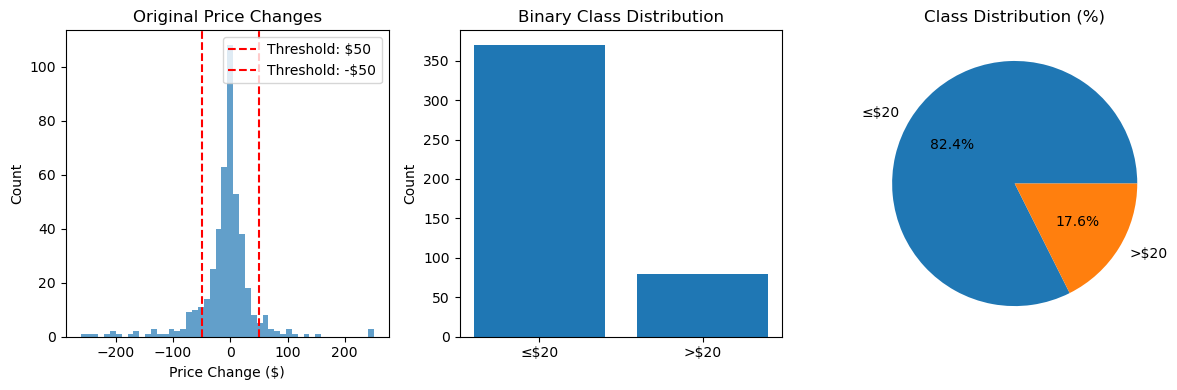

Original class distribution: {0: 370, 1: 79}
Training set: 359 samples
Validation set: 90 samples
Training class distribution: {0: 294, 1: 65}
Validation class distribution: {0: 76, 1: 14}
=== Creating Training Dataset ===
Dataset created with 359 samples
Sequence shape: (359, 5, 67)
Target shape: (359,)
=== Creating Validation Dataset ===
Dataset created with 90 samples
Sequence shape: (90, 5, 67)
Target shape: (90,)
Class counts: [180 179]
Training on cuda
Class weights: tensor([0.9972, 1.0028], device='cuda:0')
Epoch   0: Train Loss: 0.7474, Val Loss: 0.6796, Train Acc: 49.30%, Val Acc: 74.44%, Val ROC AUC: 0.5244


c:\Users\chris\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  10: Train Loss: 0.6880, Val Loss: 0.6451, Train Acc: 55.99%, Val Acc: 84.44%, Val ROC AUC: 0.6278
Epoch  20: Train Loss: 0.6958, Val Loss: 0.6228, Train Acc: 54.32%, Val Acc: 84.44%, Val ROC AUC: 0.6344
Epoch  30: Train Loss: 0.6935, Val Loss: 0.6075, Train Acc: 52.65%, Val Acc: 84.44%, Val ROC AUC: 0.6316
Epoch  40: Train Loss: 0.6835, Val Loss: 0.6045, Train Acc: 54.32%, Val Acc: 84.44%, Val ROC AUC: 0.6438
Epoch  50: Train Loss: 0.6653, Val Loss: 0.5982, Train Acc: 58.50%, Val Acc: 85.56%, Val ROC AUC: 0.6288
Epoch  60: Train Loss: 0.6756, Val Loss: 0.5944, Train Acc: 57.94%, Val Acc: 84.44%, Val ROC AUC: 0.6579
Epoch  70: Train Loss: 0.6705, Val Loss: 0.5951, Train Acc: 59.61%, Val Acc: 84.44%, Val ROC AUC: 0.6400
Epoch  80: Train Loss: 0.6821, Val Loss: 0.5976, Train Acc: 52.65%, Val Acc: 84.44%, Val ROC AUC: 0.6372
Epoch  90: Train Loss: 0.7020, Val Loss: 0.5951, Train Acc: 55.99%, Val Acc: 84.44%, Val ROC AUC: 0.6400
Epoch 100: Train Loss: 0.6705, Val Loss: 0.5955, Train 

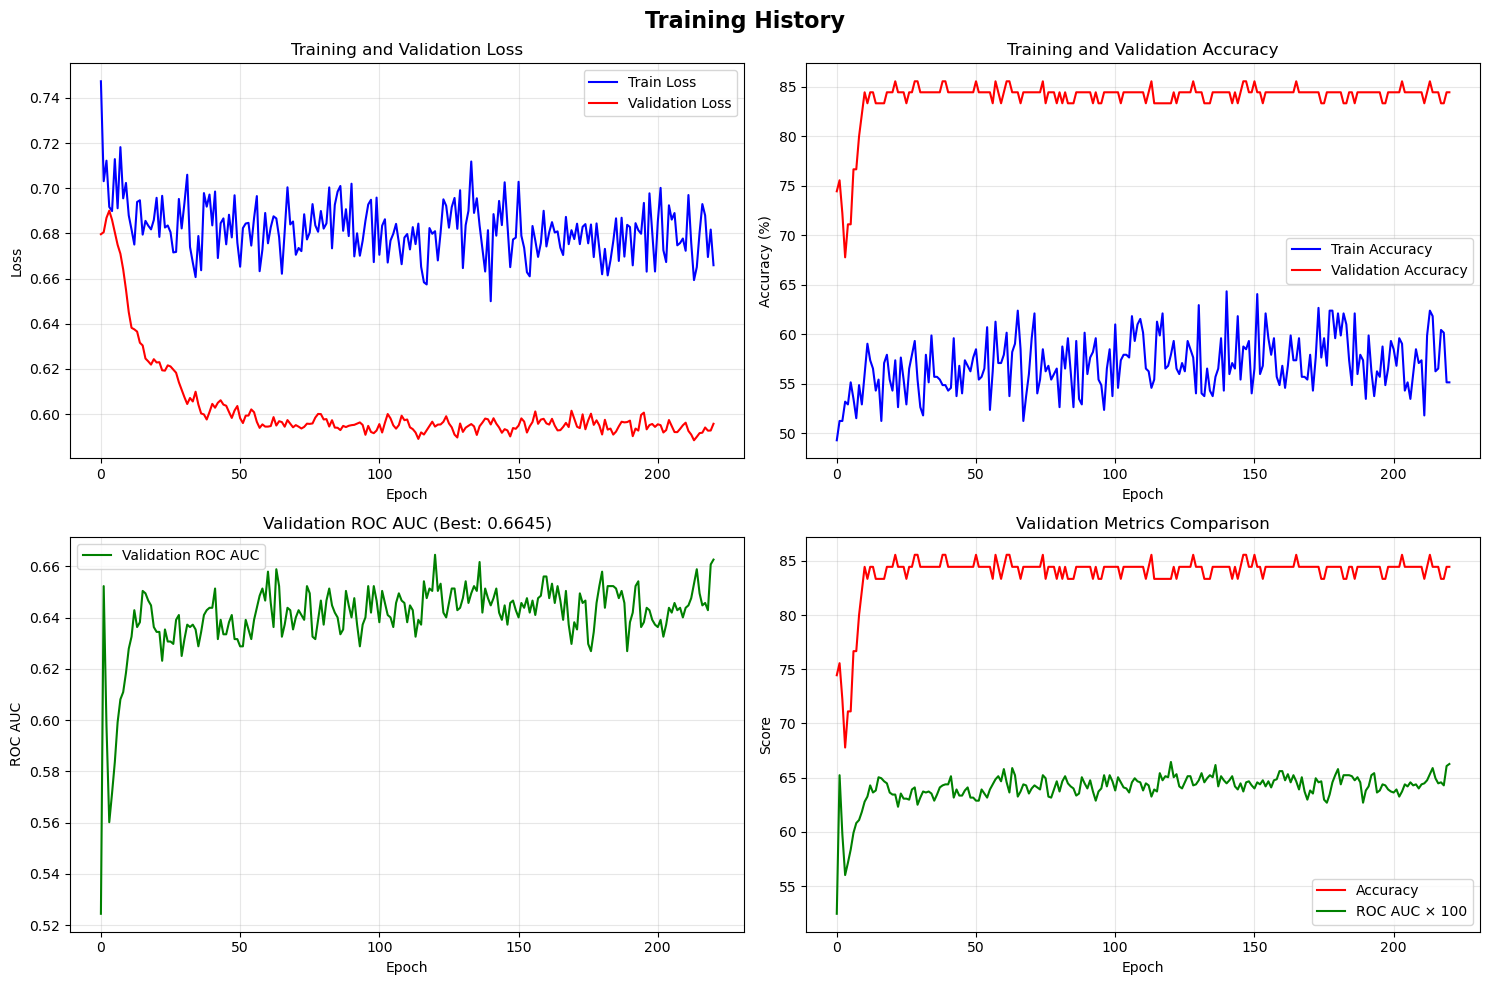

COMPREHENSIVE MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

        ≤$50       0.87      0.96      0.91        76
        >$50       0.50      0.21      0.30        14

    accuracy                           0.84        90
   macro avg       0.68      0.59      0.61        90
weighted avg       0.81      0.84      0.82        90



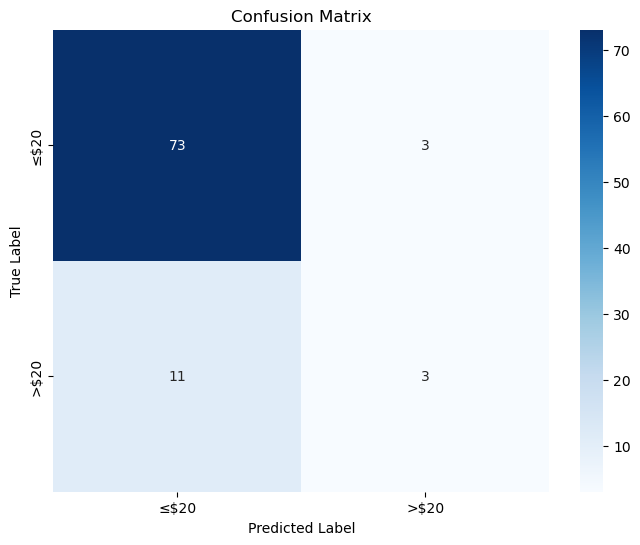

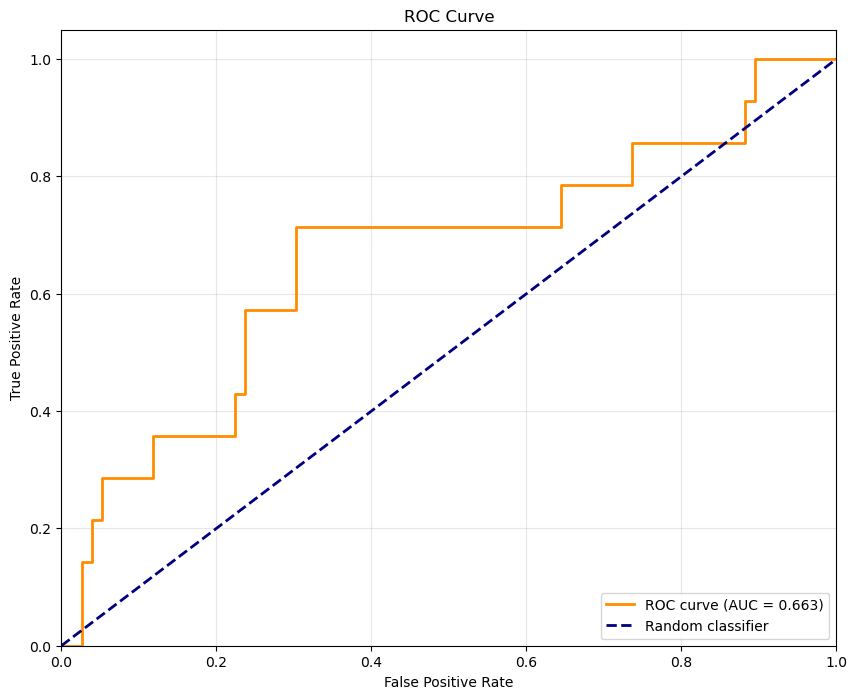


Detailed Metrics:
ROC AUC: 0.6626
Number of samples: 90
Class distribution: [76 14]
True Positives: 3
False Positives: 3
True Negatives: 73
False Negatives: 11
Precision: 0.5000
Recall: 0.2143
F1-Score: 0.3000


In [611]:
threshold = 50

Y_BINARY = convert_to_binary_classification(y_dataset, threshold=threshold)
sequences = np.array(X_dataset)

train_loader, val_loader, scaler = setup_classification_data_with_weighted_sampling(sequences, Y_BINARY, train_batch_size=64)

# 2. Create your classification model
input_features = sequences[0].shape[1]
sequence_length = sequences[0].shape[0]
model = BTCMarketMoveClassifier(input_features=input_features, sequence_length=sequence_length, num_classes=2)

# 3. Train with ROC tracking and weighted loss
trained_model, history = train_classification_model_with_roc(
    model, train_loader, val_loader, 
    num_epochs=1000, learning_rate=0.00005, 
    device='cuda' if torch.cuda.is_available() else 'cpu',
    patience=100
)

# 4. Plot training history
plot_training_history(history)

# 5. Comprehensive evaluation,
results = evaluate_model_comprehensive(trained_model, val_loader, threshold=threshold)

In [436]:
def evaluate_classification_model(model, val_loader, device):
    """Evaluate the classification model"""
    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []
    
    with torch.no_grad():
        for sequences, targets in val_loader:
            sequences, targets = sequences.to(device), targets.squeeze().to(device)
            outputs = model(sequences)
            
            # Get probabilities
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)

def plot_classification_results(predictions, targets, probabilities):
    """Plot classification results"""
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    
    # Confusion matrix
    cm = confusion_matrix(targets, predictions)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    plt.subplot(1, 3, 2)
    plt.hist(probabilities[:, 1], bins=50, alpha=0.7, label='Class 1 Probability')
    plt.title('Distribution of Class 1 Probabilities')
    plt.xlabel('Probability of >$20 Move')
    plt.ylabel('Count')
    
    plt.subplot(1, 3, 3)
    # ROC curve
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(targets, probabilities[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(targets, predictions, target_names=['≤$20', '>$20']))

=== Creating Training Dataset ===
Fitted sequence scaler
Classification Dataset created with 308 samples
Sequence shape: (308, 2, 67)
Target shape: (308,)
Class distribution: [187 121]

=== Creating Validation Dataset ===
Applied sequence scaler (no fitting)
Classification Dataset created with 78 samples
Sequence shape: (78, 2, 67)
Target shape: (78,)
Class distribution: [47 31]
Training Classification Model:
  Initial LR: 0.1
  T_0: 50, T_mult: 2, eta_min: 1e-06
Epoch 0:
  Train Loss: 8.6780, Val Loss: 0.6643
  Train Acc: 53.25%, Val Acc: 60.26%
  LR: 0.099901
Epoch 10:
  Train Loss: 0.6697, Val Loss: 0.6637
  Train Acc: 60.71%, Val Acc: 60.26%
  LR: 0.088526
Epoch 20:
  Train Loss: 0.6750, Val Loss: 0.6629
  Train Acc: 60.71%, Val Acc: 60.26%
  LR: 0.062435
Epoch 30:
  Train Loss: 0.6735, Val Loss: 0.6626
  Train Acc: 60.71%, Val Acc: 60.26%
  LR: 0.031594
Epoch 40:
  Train Loss: 0.6712, Val Loss: 0.6626
  Train Acc: 60.71%, Val Acc: 60.26%
  LR: 0.007785
Epoch 50:
  Train Loss: 0.67

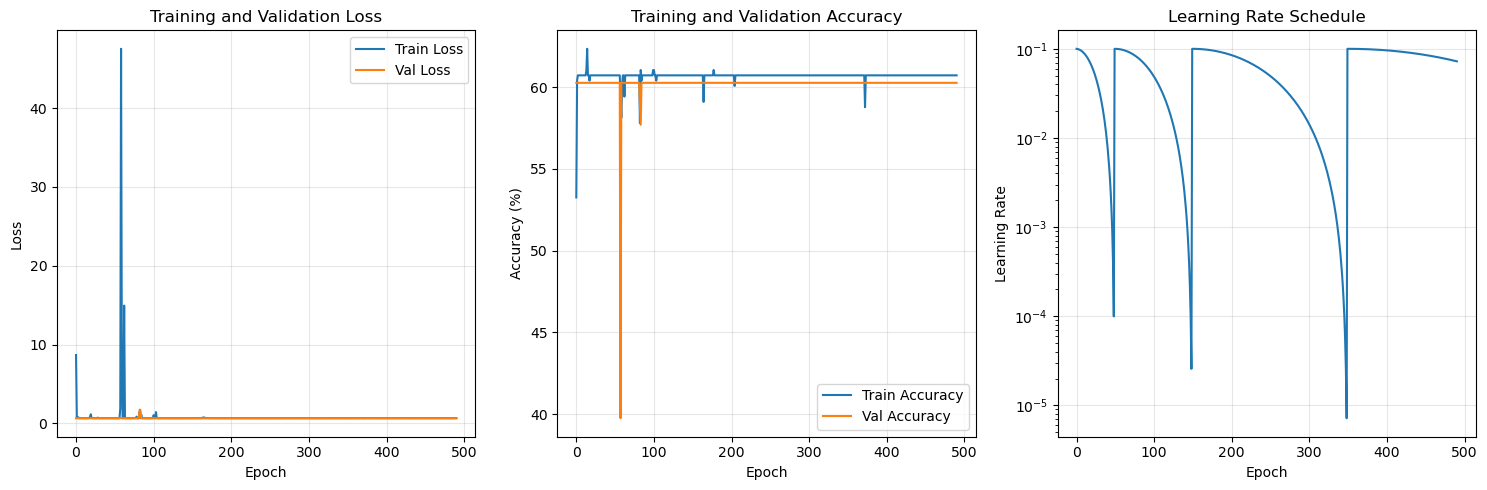

In [458]:
train_loader, val_loader, sequence_scaler = setup_classification_data(sequences, Y_BINARY)

input_features = X_dataset[0].shape[1]
sequence_length = X_dataset[0].shape[0]

model = BTCMarketMoveClassifier(input_features=input_features, sequence_length=sequence_length, num_classes=2)
trained_model, train_losses, val_losses, train_accs, val_accs = train_classification_model(
    model, train_loader, val_loader, epochs=2000, initial_lr=0.1
)

In [427]:
# Example data preparation (replace with your actual data)
sequences = np.array(X_dataset)
targets = np.array(y_ce_dataset)


dataset = BTCDataset(sequences, targets)

train_loader = dataset.get_train_loader(batch_size=1, shuffle=True)
val_loader = dataset.get_val_loader(batch_size=1, shuffle=False)

# train_loader, val_loader, sequence_scaler, target_scaler = setup_training_data(sequences, targets)


input_features = sequences[0].shape[1]
seq_length = sequences[0].shape[0]

Fitted sequence scaler - Mean: [14.0315285  13.55610104 17.82276684 15.89573446 21.02209715], Std: [37.10175881 29.00604753 40.21340173 30.36429137 52.76236764]
Fitted target scaler - Mean: 0.2902, Std: 0.4538
Dataset created with 386 samples
Sequence shape: (386, 2, 67)
Target shape: (386,)


In [430]:
# model = AdvancedFinancialPredictor(input_features=input_features, sequence_length=seq_length)
# model = ImprovedBTCPricePredictorCNN(input_features=input_features, sequence_length=seq_length)
model = BTCPricePredictorCNN(input_features=input_features, sequence_length=seq_length)

model_info(model)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.1,  # Learning rate
    weight_decay=1e-9,  # L2 regularization
    betas=(0.9, 0.999)  # Adam parameters
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 50, eta_min=0.0, last_epoch=-1)

model = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,epochs=2000)

Total parameters: 31,841
Trainable parameters: 31,841
Average inference time: 1.137 ms
Training on cuda


c:\Users\chris\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\chris\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 0: Train Loss: 2.117022, Val Loss: 1.178117
Epoch 10: Train Loss: 1.212629, Val Loss: 1.038846
Epoch 20: Train Loss: 1.192046, Val Loss: 1.203024
Epoch 30: Train Loss: 1.224279, Val Loss: 1.018527
Epoch 40: Train Loss: 1.210979, Val Loss: 1.205736


KeyboardInterrupt: 

Batch 0: outputs shape: torch.Size([32]), targets shape: torch.Size([32, 1])
Batch 1: outputs shape: torch.Size([32]), targets shape: torch.Size([32, 1])
Batch 2: outputs shape: torch.Size([14]), targets shape: torch.Size([14, 1])
Final shapes: predictions (78,), targets (78,)
Validation Metrics:
MSE: 0.501124
MAE: 0.461761
R²: -0.000470
RMSE: 0.707901


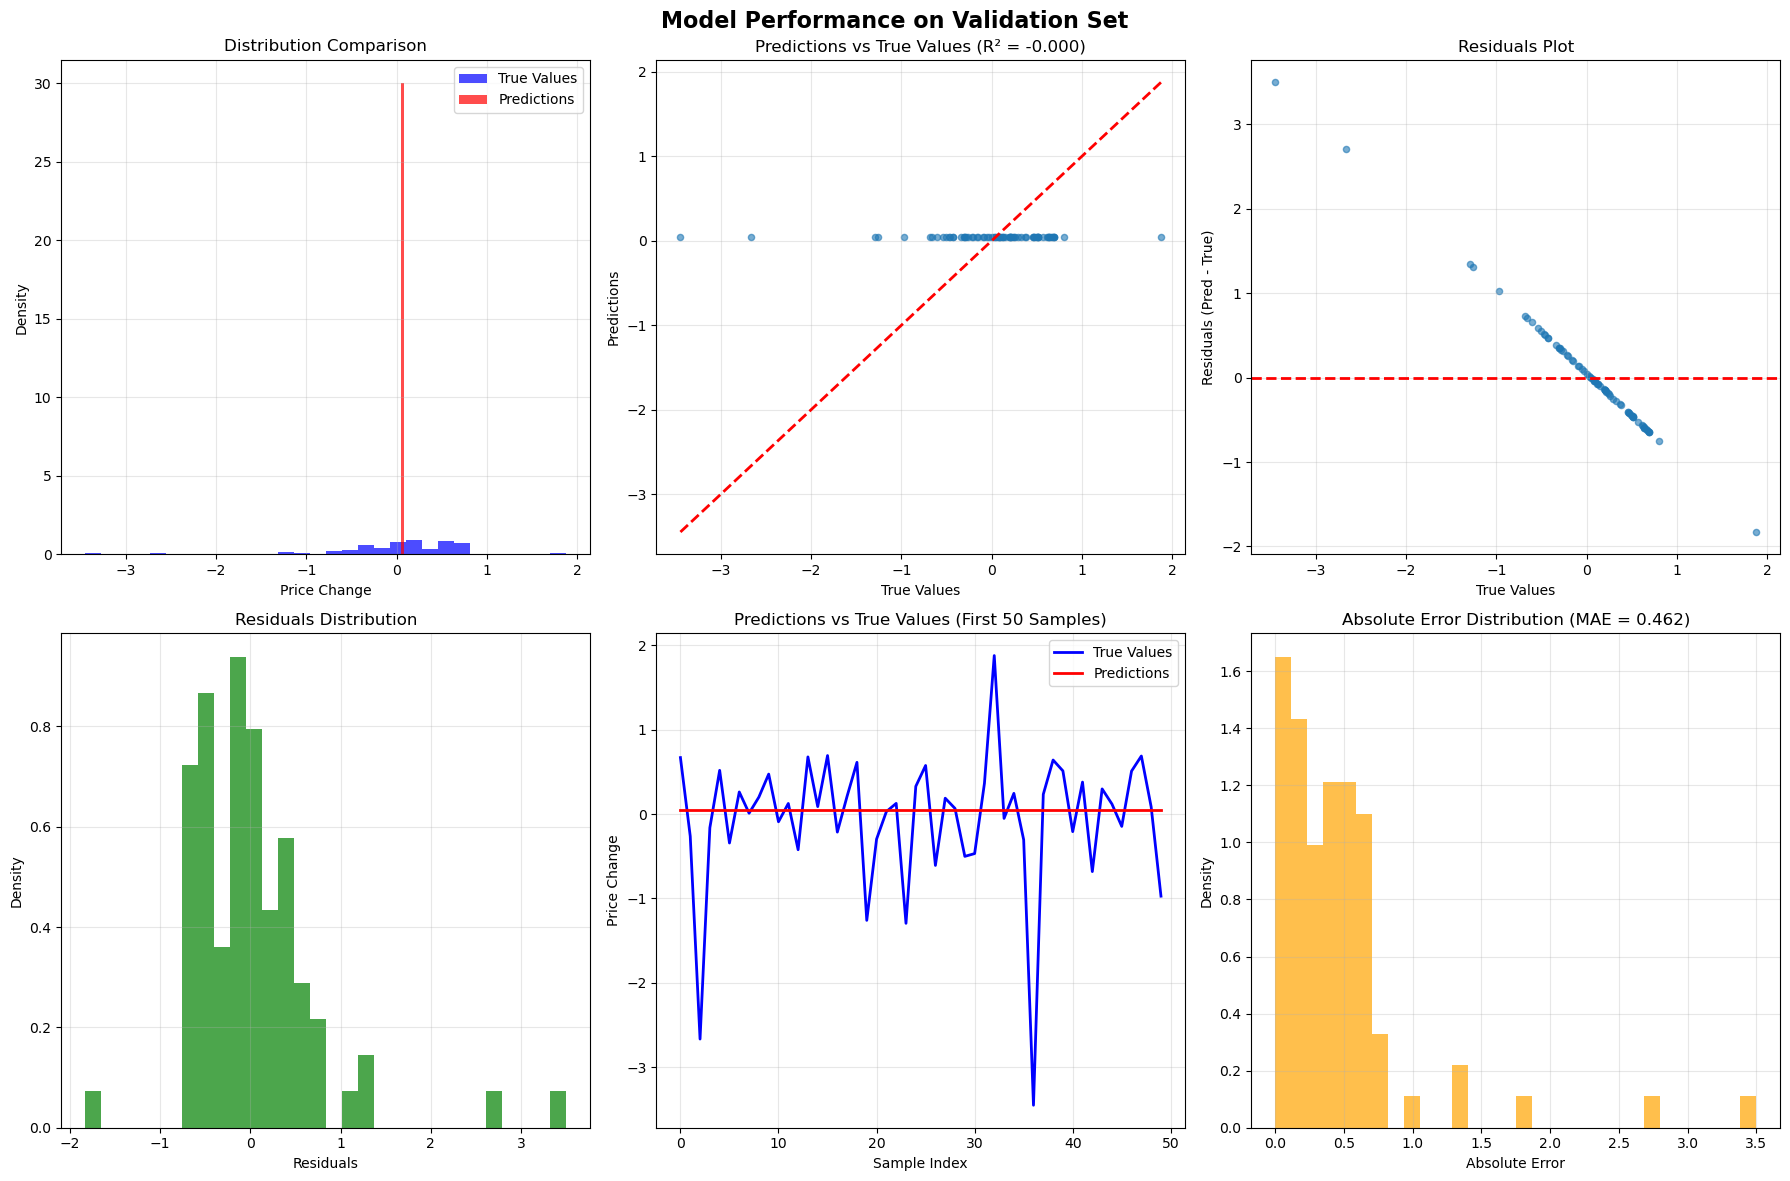


Detailed Statistics:
True values - Mean: 0.033123, Std: 0.707735
Predictions - Mean: 0.048462, Std: 0.000000
Residuals - Mean: 0.015340, Std: 0.707735
Correlation: nan
Outliers (>3σ): 2 out of 78 (2.6%)


c:\Users\chris\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\chris\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [399]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model_fixed(model, val_loader):
    """
    Fixed model evaluation that handles inconsistent tensor shapes
    """
    # Set model to evaluation mode
    model.eval()
    
    # Move model to CPU for inference
    device = torch.device('cpu')
    model = model.to(device)
    
    # Collect predictions and true values from validation set
    val_predictions = []
    val_targets = []
    
    with torch.no_grad():
        for batch_idx, (sequences, targets) in enumerate(val_loader):
            # Move data to the same device as model
            sequences = sequences.to(device)
            targets = targets.to(device)
            
            outputs = model(sequences).squeeze()
            
            # Debug: Print shapes
            print(f"Batch {batch_idx}: outputs shape: {outputs.shape}, targets shape: {targets.shape}")
            
            # Convert to numpy and ensure 1D
            outputs_np = outputs.cpu().numpy()
            targets_np = targets.cpu().numpy()
            
            # Ensure they're 1D arrays
            if outputs_np.ndim == 0:
                outputs_np = np.array([outputs_np])
            if targets_np.ndim == 0:
                targets_np = np.array([targets_np])
            
            # Flatten if needed
            outputs_np = outputs_np.flatten()
            targets_np = targets_np.flatten()
            
            val_predictions.extend(outputs_np)
            val_targets.extend(targets_np)
    
    # Convert to numpy arrays
    val_predictions = np.array(val_predictions)
    val_targets = np.array(val_targets)
    
    print(f"Final shapes: predictions {val_predictions.shape}, targets {val_targets.shape}")
    
    return val_predictions, val_targets

def plot_model_performance(val_predictions, val_targets):
    """
    Create comprehensive visualization of model performance
    """
    # Calculate metrics
    mse = mean_squared_error(val_targets, val_predictions)
    mae = mean_absolute_error(val_targets, val_predictions)
    r2 = r2_score(val_targets, val_predictions)
    
    print(f"Validation Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R²: {r2:.6f}")
    print(f"RMSE: {np.sqrt(mse):.6f}")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Performance on Validation Set', fontsize=16, fontweight='bold')
    
    # 1. Distribution comparison
    axes[0, 0].hist(val_targets, bins=30, alpha=0.7, label='True Values', color='blue', density=True)
    axes[0, 0].hist(val_predictions, bins=30, alpha=0.7, label='Predictions', color='red', density=True)
    axes[0, 0].set_xlabel('Price Change')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('Distribution Comparison')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Scatter plot
    axes[0, 1].scatter(val_targets, val_predictions, alpha=0.6, s=20)
    axes[0, 1].plot([val_targets.min(), val_targets.max()], [val_targets.min(), val_targets.max()], 'r--', lw=2)
    axes[0, 1].set_xlabel('True Values')
    axes[0, 1].set_ylabel('Predictions')
    axes[0, 1].set_title(f'Predictions vs True Values (R² = {r2:.3f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Residuals plot
    residuals = val_predictions - val_targets
    axes[0, 2].scatter(val_targets, residuals, alpha=0.6, s=20)
    axes[0, 2].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 2].set_xlabel('True Values')
    axes[0, 2].set_ylabel('Residuals (Pred - True)')
    axes[0, 2].set_title('Residuals Plot')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Residuals distribution
    axes[1, 0].hist(residuals, bins=30, alpha=0.7, color='green', density=True)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Density')
    axes[1, 0].set_title('Residuals Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Time series of predictions vs actual (first 50 samples)
    sample_size = min(50, len(val_targets))
    axes[1, 1].plot(range(sample_size), val_targets[:sample_size], 'b-', label='True Values', linewidth=2)
    axes[1, 1].plot(range(sample_size), val_predictions[:sample_size], 'r-', label='Predictions', linewidth=2)
    axes[1, 1].set_xlabel('Sample Index')
    axes[1, 1].set_ylabel('Price Change')
    axes[1, 1].set_title('Predictions vs True Values (First 50 Samples)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Error distribution
    absolute_errors = np.abs(residuals)
    axes[1, 2].hist(absolute_errors, bins=30, alpha=0.7, color='orange', density=True)
    axes[1, 2].set_xlabel('Absolute Error')
    axes[1, 2].set_ylabel('Density')
    axes[1, 2].set_title(f'Absolute Error Distribution (MAE = {mae:.3f})')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    print(f"\nDetailed Statistics:")
    print(f"True values - Mean: {val_targets.mean():.6f}, Std: {val_targets.std():.6f}")
    print(f"Predictions - Mean: {val_predictions.mean():.6f}, Std: {val_predictions.std():.6f}")
    print(f"Residuals - Mean: {residuals.mean():.6f}, Std: {residuals.std():.6f}")
    print(f"Correlation: {np.corrcoef(val_targets, val_predictions)[0,1]:.6f}")
    
    # Check for any extreme outliers
    outlier_threshold = 3 * np.std(residuals)
    outliers = np.abs(residuals) > outlier_threshold
    print(f"Outliers (>3σ): {outliers.sum()} out of {len(residuals)} ({outliers.sum()/len(residuals)*100:.1f}%)")
    
    return mse, mae, r2, residuals

# Usage example:
val_predictions, val_targets = evaluate_model_fixed(model, val_loader)
mse, mae, r2, residuals = plot_model_performance(val_predictions, val_targets)